# Task 3: CycleGAN, Monet ↔ Photo (Sneha)

Everything for Task 3 is in this one notebook: settings, data, the shared image lists, the CycleGAN written from scratch
(two U-Net generators, two 70×70 PatchGAN discriminators), training with resume, checkpoint selection on a validation set,
the Kaggle submission computed by the **provided evaluation script**, every Task 3 metric, and the human-audit helpers.

**How to run**
1. Set `SMOKE = True` and choose *Run All*: 2 tiny epochs on 16 images. It proves the notebook works. Its outputs go to `task3_gan/sneha/_smoke/`.
   **Never submit a smoke `submission.csv`.**
2. Set `train_until` in `config.yaml` to the time training must end (lab time, with its `-07:00` offset). Then set `SMOKE = False`,
   choose *Restart & Run All*, and save the notebook with its outputs. The run fits as many epochs as it can before `train_until`.
3. If a lab session ends mid-run, set `RESUME = True` and *Run All*. Training continues from the last finished epoch.
4. **Google Colab** (after the lab run stopped at epoch 73): follow section 0. Step A makes the submission from the generators saved
   in the lab. Step B resumes from the epoch-70 checkpoint and trains the learning-rate decay.

**Leaderboard integrity (brief):**
- **Allowed:** submit only this model's own inference on the fixed input lists, scored by the provided script with only its folder paths changed.
- **Not allowed:** hand-picked, edited or copied images, pretrained image models touching the outputs, or typed-in numbers.
- **Kept out of training:** the photos the script scores against.
- **Checkpoint choice:** each generator's best checkpoint is chosen on a separate validation set, not on the submission.

Domain A = Monet (`monet_jpg`) and domain B = photo (`photo_jpg`). A2B is Monet → photo; B2A is photo → Monet. These match the script's names.

## 0. Google Colab only
The lab run of 1 October stopped after epoch 73 with no error message (the process was ended on the lab machine),
and there was no lab time left before the deadline, so the run continues on Google Colab. On any other machine
the next cell does nothing.
- **Before:** upload `data266-lab1_colab.zip` (the project with the lab checkpoints) and this notebook to
  `My Drive/data266_task3/`. Open the notebook with Colab and choose a GPU (*Runtime → Change runtime type*).
- **Step A** (`STEP = "A"`, *Run all*, about 15 min): no training. It makes the submission and the metrics from `generators_best.pt`
  as saved in the lab (`config_colab_submit.yaml`: `epochs: 70`, the epoch of the checkpoint).
- **Step B** (`STEP = "B"`, *Restart session and run all*): it resumes `cyclegan_last.pt` at epoch 70 with `config_colab_resume.yaml`.
  The learning rate decays linearly to 0 over the remaining epochs (`epochs: auto`, up to `max_epochs`, ending before `train_until`).
- **Backups:** every 20 minutes, the run's files are copied to `data266_task3/backup/` on Drive.
  If Colab disconnects, open the notebook again, keep `STEP = "B"` and *Run all*: it restores the backup and resumes.
- **At the end:** the last cell copies everything to Drive and adds a results zip there. Then save this notebook (*File → Save*).

In [1]:
# Google Colab only; on any other machine this cell does nothing (section 0).
import os, sys
COLAB = "google.colab" in sys.modules
if COLAB:
    STEP = "B"    # A: submission from the generators saved in the lab, no training | B: resume and train the decay
    import pathlib, shutil, subprocess, threading, time, zipfile
    from google.colab import drive
    assert shutil.which("nvidia-smi"), "no GPU: Runtime > Change runtime type > a GPU, then run this cell again"
    drive.mount("/content/drive")
    DRIVE_DIR = pathlib.Path("/content/drive/MyDrive/data266_task3")   # holds data266-lab1_colab.zip
    BACKUP = DRIVE_DIR / "backup"                                     # the run's files, refreshed every 20 min
    LOCAL = pathlib.Path("/content/data266-lab1")                     # the local disk: much faster than Drive
    BACKED_UP = ("task3_gan/sneha", "reproducibility")   # except *_last.pt: the Drive has no room for it
    _copied, _last_big = {}, [0.0]

    def _run_files():
        for top in BACKED_UP:
            for p in sorted((LOCAL / top).rglob("*")):
                parts = p.relative_to(LOCAL).parts
                if p.is_file() and not p.name.endswith("_last.pt") \
                        and not {"_smoke", "src", ".ipynb_checkpoints"} & set(parts) \
                        and not any(s.startswith("val_") for s in parts):     # val_*: validation scratch
                    yield p

    if not LOCAL.exists():
        with zipfile.ZipFile(DRIVE_DIR / "data266-lab1_colab.zip") as z:
            z.extractall("/content")
        if BACKUP.exists():                                           # a new Colab session: continue from the backup
            shutil.copytree(BACKUP, LOCAL, dirs_exist_ok=True)
            print(f"restored the newest backup from {BACKUP}")
        for p in _run_files():                                        # already on Drive: copy only what changes
            _copied[p] = (p.stat().st_size, p.stat().st_mtime)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "lpips==0.1.4"], check=True)
    os.environ["DATA266_CONFIG"] = {"A": "task3_gan/sneha/config_colab_submit.yaml",
                                    "B": "task3_gan/sneha/config_colab_resume.yaml"}[STEP]
    os.environ["DATA266_RESUME"] = "1"
    os.chdir(LOCAL)

    def colab_backup(final: bool = False) -> int:
        """Copy the run's new or changed files to BACKUP on Drive. A file changed in the last minute is still
        being written and waits for the next round, except the CSVs and logs: they are written all the time, so
        they are copied up to their last complete line. Files over 100 MB go together and at most once an hour,
        because every copy of the 2 GB resume checkpoint uses Drive space until the Drive trash is emptied."""
        now, todo = time.time(), []
        for p in _run_files():
            s = p.stat()
            if _copied.get(p) != (s.st_size, s.st_mtime):
                todo.append((p, s, s.st_size > 100e6, p.suffix in (".csv", ".log") and not final))
        big_busy = any(big and now - s.st_mtime < 60 for _, s, big, _ in todo)
        big_ok = final or (not big_busy and now - _last_big[0] > 3600)
        n = 0
        for p, s, big, live in todo:
            if (big and not big_ok) or (not final and not live and now - s.st_mtime < 60):
                continue
            dst = BACKUP / p.relative_to(LOCAL)
            dst.parent.mkdir(parents=True, exist_ok=True)
            tmp = dst.with_name(dst.name + ".part")
            whole = True
            if live:
                data = p.read_bytes()
                cut = data.rfind(b"\n") + 1
                tmp.write_bytes(data[:cut])
                whole = cut == len(data)                                # else the cut-off line goes next round
            else:
                shutil.copyfile(p, tmp)
                if (p.stat().st_size, p.stat().st_mtime) != (s.st_size, s.st_mtime):   # rewritten meanwhile
                    tmp.unlink()
                    continue
            os.replace(tmp, dst)
            n += 1
            if whole:
                _copied[p] = (s.st_size, s.st_mtime)
            if big:
                _last_big[0] = now
        return n

    def _backup_every_20_min():
        while True:
            time.sleep(1200)
            try:
                colab_backup()
            except Exception as e:                                    # a Drive hiccup: the next round retries
                print(f"[drive backup] failed this round ({type(e).__name__}: {e})")

    if not any(t.name == "drive-backup" for t in threading.enumerate()):
        threading.Thread(target=_backup_every_20_min, name="drive-backup", daemon=True).start()
    gpu = subprocess.check_output(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"], text=True)
    print(f"Colab step {STEP} | GPU {gpu.strip()} | settings {os.environ['DATA266_CONFIG']} | RESUME on\n"
          f"project {LOCAL} | backup every 20 min to {BACKUP}")

Mounted at /content/drive
Colab step B | GPU Tesla T4, 15360 MiB | settings task3_gan/sneha/config_colab_resume.yaml | RESUME on
project /content/data266-lab1 | backup every 20 min to /content/drive/MyDrive/data266_task3/backup


## 1. Settings
Every hyperparameter and path is in `task3_gan/sneha/config.yaml`, so the run is config-driven and nothing below hard-codes a value. Values marked SHARED there must match Ayush's settings. Set `SMOKE` and `RESUME` here.

In [2]:
SMOKE  = False    # True: 2 tiny epochs on 16 images; proves the notebook runs. Never submit its CSV.
RESUME = False    # True: continue an interrupted run from checkpoints/cyclegan_last.pt

# Every hyperparameter and path lives in task3_gan/sneha/config.yaml: "config" for the real run,
# "smoke" for the overrides that SMOKE = True applies. smoke_test.py sets DATA266_SMOKE=1; the Colab
# cell (section 0) sets DATA266_RESUME=1 and DATA266_CONFIG, the settings file for its step.
import os, pathlib, yaml
SMOKE = SMOKE or os.environ.get("DATA266_SMOKE") == "1"
RESUME = RESUME or os.environ.get("DATA266_RESUME") == "1"
_root = next(p for p in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]
             if (p / "requirements.txt").is_file())
CONFIG_FILE = _root / os.environ.get("DATA266_CONFIG", "task3_gan/sneha/config.yaml")
_settings = yaml.safe_load(CONFIG_FILE.read_text(encoding="utf-8"))
CONFIG, SMOKE_OVERRIDES = _settings["config"], _settings["smoke"]
print(f"settings from {CONFIG_FILE.relative_to(_root).as_posix()} | SMOKE = {SMOKE} | RESUME = {RESUME}")

settings from task3_gan/sneha/config_colab_resume.yaml | SMOKE = False | RESUME = True


## 2. Setup

In [3]:
import contextlib, copy, csv, hashlib, io, json, logging, math, os, platform, random, re, shutil, subprocess, sys
import tempfile, time, zipfile
from datetime import datetime
from importlib import metadata
from pathlib import Path

import lpips
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.linalg
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models
import torchvision.transforms as T
import yaml
from IPython.display import Image, display
from PIL import Image as PILImage
from sklearn.metrics import cohen_kappa_score

ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
            if (p / "requirements.txt").is_file())
os.chdir(ROOT)


class Cfg(dict):
    """The settings dict with attribute access: cfg.epochs."""
    def __getattr__(self, key):
        try:
            return self[key]
        except KeyError as e:
            raise AttributeError(key) from e


cfg = Cfg({**CONFIG, **(SMOKE_OVERRIDES if SMOKE else {})})
CFG_HASH = hashlib.sha256(json.dumps(cfg, sort_keys=True, separators=(",", ":"),
                                     ensure_ascii=False).encode("utf-8")).hexdigest()
LAMBDA_IDT = cfg.lambda_cycle * cfg.lambda_identity_ratio


def rel(p) -> str:
    """Repo-relative path for logs and manifests, so no personal path is ever recorded."""
    p = Path(p).resolve()
    try:
        return p.relative_to(ROOT).as_posix()
    except ValueError:
        return p.as_posix()


DATA = ROOT / cfg.data_dir
MONET_DIR, PHOTO_DIR = DATA / "monet_jpg", DATA / "photo_jpg"
OUT = ROOT / cfg.out_dir
CKPT_DIR, OUTPUTS = OUT / "checkpoints", OUT / "outputs"
PRED_A2B, PRED_B2A = OUTPUTS / "pred_A2B", OUTPUTS / "pred_B2A"
for d in (CKPT_DIR, OUTPUTS, ROOT / cfg.logs_dir, ROOT / cfg.manifests_dir):
    d.mkdir(parents=True, exist_ok=True)
LAST_CKPT, BEST_GEN = CKPT_DIR / "cyclegan_last.pt", CKPT_DIR / "generators_best.pt"
FINAL_GEN = CKPT_DIR / "generators_final.pt"
ITER_CSV, HISTORY, SUMMARY = OUTPUTS / "train_iters.csv", OUTPUTS / "history.json", OUTPUTS / "train_summary.json"
SUBMISSION, METRICS_CSV = OUT / "submission.csv", OUT / "metrics_report.csv"
MANIFEST = ROOT / cfg.manifests_dir / (f"{cfg.member}_task3.json" if cfg.run_name == "main"
                                       else f"{cfg.member}_task3_{cfg.run_name}.json")
print(f"repo {ROOT.name} | {'SMOKE' if SMOKE else 'REAL'} run '{cfg.run_name}' | settings sha256 {CFG_HASH[:12]} | "
      f"identity weight {LAMBDA_IDT} | outputs -> {rel(OUT)}")

repo data266-lab1 | REAL run 'main' | settings sha256 31712f3f87ed | identity weight 5.0 | outputs -> task3_gan/sneha


## 3. Reproducibility helpers

In [4]:
def set_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = cfg.cudnn_benchmark
    torch.backends.cudnn.deterministic = not cfg.cudnn_benchmark


def arch_supported(cap: tuple[int, int], archs: list[str]) -> bool:
    """CUDA rules: an sm_XY binary runs on any sm_XZ with Z >= Y (same major version);
    compute_XY PTX can be JIT-compiled for any newer card. torch 2.4.1 serves the RTX 4090
    (sm_89) with its sm_86 binaries; an RTX 5090 (sm_120) needs torch >= 2.7."""
    major, minor = cap
    c = 10 * major + minor
    return not archs or any(
        (a.startswith("sm_") and int(a[3:]) // 10 == major and int(a[3:]) <= c)
        or (a.startswith("compute_") and int(a[8:]) <= c) for a in archs)


def get_device(requested: str) -> torch.device:
    """cuda: a supported GPU or an error, never a silent CPU fallback. auto: GPU if present. cpu: CPU."""
    if requested == "cpu":
        return torch.device("cpu")
    if requested not in ("cuda", "auto"):
        raise ValueError(f"device must be cuda, auto or cpu, not {requested!r}")
    if torch.cuda.is_available():
        cap = torch.cuda.get_device_capability(0)
        if not arch_supported(cap, torch.cuda.get_arch_list()):
            raise RuntimeError(f"{torch.cuda.get_device_name(0)} (sm_{cap[0]}{cap[1]}) is not "
                               f"supported by torch {torch.__version__}. Use an RTX 4090.")
        return torch.device("cuda")
    if requested == "auto":
        return torch.device("cpu")
    raise RuntimeError(f"device='cuda' but torch {torch.__version__} sees no CUDA GPU "
                       f"(torch.version.cuda = {torch.version.cuda}; None means a CPU-only "
                       f"wheel: reinstall with the README's CUDA command). For a deliberate "
                       f"CPU run set device='auto' or 'cpu'.")


def device_name(device: torch.device) -> str:
    return torch.cuda.get_device_name(device) if device.type == "cuda" else "cpu"


def cpu_name() -> str:
    return platform.processor() or platform.machine()


def sync(device: torch.device) -> None:
    if device.type == "cuda":
        torch.cuda.synchronize(device)


def reset_peak_mem() -> None:
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()


def peak_mem_gb() -> float:
    return torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else 0.0


def git_sha() -> str:
    """The checked-out commit. Reads .git directly when the git program is missing
    (the lab's Docker container has none)."""
    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=ROOT, text=True,
                                       stderr=subprocess.DEVNULL).strip()
    except Exception:
        pass
    try:
        g = ROOT / ".git"
        head = (g / "HEAD").read_text().strip()
        if not head.startswith("ref: "):
            return head                                   # detached HEAD: the hash itself
        ref = head[5:]
        if (g / ref).exists():
            return (g / ref).read_text().strip()
        packed = g / "packed-refs"
        for line in (packed.read_text().splitlines() if packed.exists() else []):
            if line.endswith(" " + ref):
                return line.split()[0]
    except Exception:
        pass
    return "unknown"


def installed_packages() -> list[str]:
    return sorted(f"{d.metadata['Name']}=={d.version}" for d in metadata.distributions())


def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while block := f.read(1 << 20):
            h.update(block)
    return h.hexdigest()


def open_run_log(stage: str) -> tuple[logging.Logger, Path]:
    """A new timestamped raw log, opened in mode "x" so an existing log can never be
    overwritten. Every line goes to the file; INFO lines also show in the notebook."""
    stamp = time.strftime("%Y%m%dT%H%M%SZ", time.gmtime())
    path = ROOT / cfg.logs_dir / f"task3_{stage}_{cfg.run_name}_{stamp}.log"
    while path.exists():
        time.sleep(1)
        stamp = time.strftime("%Y%m%dT%H%M%SZ", time.gmtime())
        path = ROOT / cfg.logs_dir / f"task3_{stage}_{cfg.run_name}_{stamp}.log"
    logger = logging.getLogger(f"task3.{stage}.{cfg.run_name}.{stamp}")
    logger.setLevel(logging.DEBUG)
    logger.propagate = False
    logger.handlers.clear()
    fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
    fh = logging.FileHandler(path, mode="x", encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    sh = logging.StreamHandler(sys.stdout)
    sh.setLevel(logging.INFO)
    for h in (fh, sh):
        h.setFormatter(fmt)
        logger.addHandler(h)
    logger.info(f"config_sha256 {CFG_HASH}")           # first line, always
    logger.info(f"git_sha {git_sha()} | notebook task3_gan/sneha/src/task3_gan_sneha.ipynb")
    logger.info(f"device {DEVICE.type} | {device_name(DEVICE)} | cpu {cpu_name()}")
    logger.info(f"torch {torch.__version__} | cuda {torch.version.cuda} | python "
                f"{platform.python_version()} | platform {platform.platform()}")
    logger.debug("config " + json.dumps(cfg, sort_keys=True, ensure_ascii=False))
    logger.debug("packages " + json.dumps(installed_packages()))
    logger.info(f"log_path {rel(path)}")
    return logger, path


def close_run_log(logger: logging.Logger) -> None:
    for h in list(logger.handlers):
        h.close()
        logger.removeHandler(h)


def snapshot_config(log_path: Path) -> None:
    (OUT / "config_used.yaml").write_text(
        f"# settings of the most recent run; sha256 {CFG_HASH}\n"
        + yaml.safe_dump(dict(cfg), sort_keys=False, allow_unicode=True), encoding="utf-8")
    logs_md = OUT / "logs.md"
    if not logs_md.exists():
        logs_md.write_text("# Raw logs for this task\n\nAppended automatically at the start of "
                           "every stage. The logs themselves are never edited.\n\n", encoding="utf-8")
    with open(logs_md, "a", encoding="utf-8") as f:
        f.write(f"- `{rel(log_path)}` (run `{cfg.run_name}`, settings sha256 `{CFG_HASH[:12]}`)\n")


set_seeds(cfg.seed)
DEVICE = get_device(cfg.device)
print(f"device: {device_name(DEVICE)} | cpu: {cpu_name()} | torch {torch.__version__} | cuda {torch.version.cuda}")

device: Tesla T4 | cpu: x86_64 | torch 2.11.0+cu130 | cuda 13.0


## 4. Data and the shared image lists (SHARED with Ayush)
- **The data:** extracted from `task3_gan/data/dataset.zip` (the course's zip: 300 Monets and 7,038 photos, all 256×256), if the folders aren't there yet.
- **The lists:** made once with seed 42, then **loaded, never redrawn.** Commit them, and Ayush uses the same files.

| List | What it is |
|---|---|
| `ref_photos_300.txt` | The first 300 photos by filename: exactly what the provided script scores Monet → photo against. **Never trained on.** |
| `eval_photos_300.txt` | The photo → Monet submission inputs |
| `val_photos_300.txt` | Checkpoint selection only |
| `photo_train_all_6138.txt` | The training photos (`train_photos: all`): every photo not in the three lists above |
| `photo_subset_2000.txt` | The earlier 2,000-photo training list (`train_photos: subset`) |

The three held-out lists and either training list are disjoint. All 300 Monets are used for training, because there are no others. The script also scores photo → Monet
against them, which is the same for every team.

In [5]:
def extract_dataset() -> None:
    z = ROOT / cfg.dataset_zip
    if not z.exists():
        raise FileNotFoundError(f"put the course's dataset.zip at {cfg.dataset_zip} (from the Part3 folder), "
                                f"or unzip it so that {cfg.data_dir}/monet_jpg and photo_jpg exist")
    with zipfile.ZipFile(z) as zf:
        for m in zf.infolist():
            parts = Path(m.filename).parts
            if m.is_dir() or "__MACOSX" in parts or parts[-1].startswith("._") or not parts[-1].lower().endswith(".jpg"):
                continue
            sub = next((p for p in parts if p in ("monet_jpg", "photo_jpg")), None)
            if sub:
                dest = DATA / sub / parts[-1]
                dest.parent.mkdir(parents=True, exist_ok=True)
                with zf.open(m) as src, open(dest, "wb") as out:
                    shutil.copyfileobj(src, out)


def jpgs(folder: Path) -> list[str]:
    return sorted(p.stem for p in folder.glob("*.jpg"))


def make_lists(photos: list[str], n_ref, n_eval, n_val, n_train, seed) -> dict[str, list[str]]:
    """ref = the first n_ref sorted photos (the script's own reference); the others are drawn
    from the remaining photos with one seeded permutation, then each list is sorted."""
    photos = sorted(photos)
    ref, rest = photos[:n_ref], photos[n_ref:]
    perm = [rest[i] for i in np.random.default_rng(seed).permutation(len(rest))]
    ev, va, tr = perm[:n_eval], perm[n_eval:n_eval + n_val], perm[n_eval + n_val:n_eval + n_val + n_train]
    return {"ref_photos": sorted(ref), "eval_photos": sorted(ev), "val_photos": sorted(va), "photo_subset": sorted(tr)}


if not (MONET_DIR.is_dir() and PHOTO_DIR.is_dir()):
    extract_dataset()
monet_all, photo_all = jpgs(MONET_DIR), jpgs(PHOTO_DIR)
print(f"monet_jpg: {len(monet_all)} images | photo_jpg: {len(photo_all)} images")

LIST_FILES = {"ref_photos": DATA / f"ref_photos_{CONFIG['n_ref_photos']}.txt",
              "eval_photos": DATA / f"eval_photos_{CONFIG['n_eval_photos']}.txt",
              "val_photos": DATA / f"val_photos_{CONFIG['n_val_photos']}.txt",
              "photo_subset": DATA / f"photo_subset_{CONFIG['photo_subset']}.txt"}
if all(p.exists() for p in LIST_FILES.values()):
    lists = {k: p.read_text(encoding="utf-8").split() for k, p in LIST_FILES.items()}
    print("loaded the existing image lists (not redrawn)")
else:
    lists = make_lists(photo_all, CONFIG["n_ref_photos"], CONFIG["n_eval_photos"], CONFIG["n_val_photos"],
                       CONFIG["photo_subset"], CONFIG["list_seed"])
    for k, p in LIST_FILES.items():
        p.write_text("\n".join(lists[k]) + "\n", encoding="utf-8")
    (DATA / "lists_info.json").write_text(json.dumps({
        "seed": CONFIG["list_seed"], "sizes": {k: len(v) for k, v in lists.items()},
        "ref_photos": "first photos in sorted filename order = the provided script's REAL_PHOTO set at N_EVAL",
        "others": "one numpy default_rng(seed) permutation of the remaining photos, then sorted",
        "files": {p.name: sha256_file(p) for p in LIST_FILES.values()},
        "made_by": "task3_gan/sneha/src/task3_gan_sneha.ipynb, section 4"}, indent=2), encoding="utf-8")
    print("CREATED the image lists. Commit task3_gan/data/*.txt and lists_info.json and share them with Ayush.")

names = list(lists)
for i, a in enumerate(names):
    for b in names[i + 1:]:
        assert not set(lists[a]) & set(lists[b]), f"{a} and {b} overlap"
assert lists["ref_photos"] == photo_all[:CONFIG["n_ref_photos"]], "ref list must be the script's first sorted photos"
assert set().union(*lists.values()) <= set(photo_all), "a listed photo is missing from photo_jpg"
held_out = set(lists["ref_photos"]) | set(lists["eval_photos"]) | set(lists["val_photos"])
if cfg.train_photos == "all":                        # every photo outside the three held-out lists
    train_photos = [p for p in photo_all if p not in held_out]
    TRAIN_LIST = DATA / f"photo_train_all_{len(train_photos)}.txt"
    if TRAIN_LIST.exists():
        assert TRAIN_LIST.read_text(encoding="utf-8").split() == train_photos, f"{TRAIN_LIST.name} does not match photo_jpg"
    else:
        TRAIN_LIST.write_text("\n".join(train_photos) + "\n", encoding="utf-8")
        print(f"CREATED {TRAIN_LIST.name}. Commit it and share it with Ayush.")
elif cfg.train_photos == "subset":
    train_photos, TRAIN_LIST = lists["photo_subset"], LIST_FILES["photo_subset"]
else:
    raise ValueError(f"train_photos must be all or subset, not {cfg.train_photos!r}")
assert not set(train_photos) & held_out, "a training photo is in a held-out list"
LIST_SHA = {p.name: sha256_file(p) for p in [*LIST_FILES.values(), TRAIN_LIST]}
lim = (lambda xs: xs[: cfg.n_limit]) if cfg.n_limit else (lambda xs: xs)
SETS = {"monet": lim(monet_all), "eval_photos": lim(lists["eval_photos"]), "val_photos": lim(lists["val_photos"]),
        "ref_photos": lim(lists["ref_photos"]), "train_photos": train_photos, "train_monet": monet_all}
print({k: len(v) for k, v in SETS.items()}, "| training photos from", rel(TRAIN_LIST))

monet_jpg: 300 images | photo_jpg: 7038 images
loaded the existing image lists (not redrawn)
{'monet': 300, 'eval_photos': 300, 'val_photos': 300, 'ref_photos': 300, 'train_photos': 6138, 'train_monet': 300} | training photos from task3_gan/data/photo_train_all_6138.txt


## 5. Model: the CycleGAN, written from scratch (brief 3.1.2)
- **Generators:** the U-Net-256 from the official CycleGAN/pix2pix code: 8 stride-2 encoder convolutions down to 1×1, with skip connections.
  The outermost and innermost encoder convolutions have no normalisation. At 1×1 there's a single value per channel, so InstanceNorm
  would erase it, and PyTorch refuses. ResNet-9 (the paper's own choice) is available as an option.
- **Discriminators:** the 70×70 PatchGAN. C64 (no norm), C128 and C256 use stride 2; **C512 uses stride 1**; then a 1-channel stride-1 convolution.
  On a 256×256 input this gives a 30×30 score map, each score seeing a 70×70 patch. With stride 2 everywhere, it would be 15×15, each seeing 94×94.
- **Norm and init:** InstanceNorm (affine, no running statistics) throughout. Weights start from N(0, 0.02). No sigmoid on the discriminator, because LSGAN uses raw scores.

In [6]:
def norm(c: int) -> nn.Module:
    return nn.InstanceNorm2d(c, affine=True, track_running_stats=False)


class UnetBlock(nn.Module):
    """One U-Net level: down-convolution, the inner levels, up-convolution, then concatenate the
    input as the skip. (Not in-place activations: the official code's in-place LeakyReLU
    silently changes the tensor that is concatenated as the skip.)"""

    def __init__(self, outer, inner, in_ch=None, sub=None, outermost=False, innermost=False, dropout=0.0):
        super().__init__()
        self.outermost, self.innermost = outermost, innermost
        in_ch = in_ch or outer
        down = nn.Conv2d(in_ch, inner, 4, 2, 1)
        if outermost:
            layers = [down, sub, nn.ReLU(), nn.ConvTranspose2d(inner * 2, outer, 4, 2, 1), nn.Tanh()]
        elif innermost:
            layers = [nn.LeakyReLU(0.2), down, nn.ReLU(), nn.ConvTranspose2d(inner, outer, 4, 2, 1), norm(outer)]
        else:
            layers = [nn.LeakyReLU(0.2), down, norm(inner), sub, nn.ReLU(),
                      nn.ConvTranspose2d(inner * 2, outer, 4, 2, 1), norm(outer)]
            if dropout:
                layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x) if self.outermost else torch.cat([x, self.model(x)], 1)


class UnetGenerator(nn.Module):
    def __init__(self, ngf=64, dropout=0.0):
        super().__init__()
        b = UnetBlock(ngf * 8, ngf * 8, innermost=True)                     # 2x2 -> 1x1 -> 2x2
        for _ in range(3):
            b = UnetBlock(ngf * 8, ngf * 8, sub=b, dropout=dropout)
        b = UnetBlock(ngf * 4, ngf * 8, sub=b)
        b = UnetBlock(ngf * 2, ngf * 4, sub=b)
        b = UnetBlock(ngf, ngf * 2, sub=b)
        self.model = UnetBlock(3, ngf, in_ch=3, sub=b, outermost=True)      # 256 -> 128, no norm

    def forward(self, x):
        return self.model(x)


class ResnetBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.block = nn.Sequential(nn.ReflectionPad2d(1), nn.Conv2d(c, c, 3), norm(c), nn.ReLU(),
                                   nn.ReflectionPad2d(1), nn.Conv2d(c, c, 3), norm(c))

    def forward(self, x):
        return x + self.block(x)


class ResnetGenerator(nn.Module):
    """The CycleGAN paper's 256x256 generator: c7s1-64, d128, d256, 9 x R256, u128, u64, c7s1-3."""

    def __init__(self, ngf=64, n_blocks=9):
        super().__init__()
        layers = [nn.ReflectionPad2d(3), nn.Conv2d(3, ngf, 7), norm(ngf), nn.ReLU()]
        for m in (1, 2):
            layers += [nn.Conv2d(ngf * m, ngf * m * 2, 3, 2, 1), norm(ngf * m * 2), nn.ReLU()]
        layers += [ResnetBlock(ngf * 4) for _ in range(n_blocks)]
        for m in (4, 2):
            layers += [nn.ConvTranspose2d(ngf * m, ngf * m // 2, 3, 2, 1, output_padding=1), norm(ngf * m // 2), nn.ReLU()]
        layers += [nn.ReflectionPad2d(3), nn.Conv2d(ngf, 3, 7), nn.Tanh()]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class PatchDiscriminator(nn.Module):
    """70x70 PatchGAN: raw (no sigmoid) 30x30 scores on a 256x256 input."""

    def __init__(self, ndf=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1), norm(ndf * 2), nn.LeakyReLU(0.2),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1), norm(ndf * 4), nn.LeakyReLU(0.2),
            nn.Conv2d(ndf * 4, ndf * 8, 4, 1, 1), norm(ndf * 8), nn.LeakyReLU(0.2),   # stride 1
            nn.Conv2d(ndf * 8, 1, 4, 1, 1))

    def forward(self, x):
        return self.model(x)


def init_weights(m: nn.Module) -> None:
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        nn.init.zeros_(m.bias)
    elif isinstance(m, nn.InstanceNorm2d) and m.affine:
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.zeros_(m.bias)


def build_generator() -> nn.Module:
    g = UnetGenerator(cfg.ngf, cfg.unet_dropout) if cfg.generator == "unet256" else \
        ResnetGenerator(cfg.ngf) if cfg.generator == "resnet9" else None
    if g is None:
        raise ValueError(f"generator must be unet256 or resnet9, not {cfg.generator!r}")
    g.apply(init_weights)
    return g


def build_discriminator() -> nn.Module:
    d = PatchDiscriminator(cfg.ndf)
    d.apply(init_weights)
    return d


def num_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters())


def receptive_field(layers) -> int:
    r, j = 1, 1
    for m in layers:
        if isinstance(m, nn.Conv2d):
            r += (m.kernel_size[0] - 1) * j
            j *= m.stride[0]
    return r

## 6. Training pieces
- **Image pool:** 50 past fakes per discriminator, sampled with probability 0.5.
- **LSGAN losses:** the adversarial loss is least squares.
- **DiffAugment:** a differentiable translation and cutout applied to every real and fake image a discriminator sees, so it can't memorise 300 Monets.
- **EMA of the generators:** an exponential moving average of the generator weights.
- **The paper's learning-rate schedule:** constant for half the epochs, then linear decay to 0.
- **Run length (`epochs: auto`):** as many epochs as fit before `train_until`. The plan starts from the pre-flight timing and is
  re-planned from the measured speed while the lr is still constant, so the past schedule never changes. The final numbers are
  logged and saved; setting `epochs` and `decay_start_epoch` to them reproduces the run.

In [7]:
class ImagePool:
    """History of generated images (Shrivastava et al. 2017, as in CycleGAN)."""

    def __init__(self, size: int):
        self.size, self.images = size, []

    def query(self, img: torch.Tensor) -> torch.Tensor:
        if self.size == 0:
            return img
        if len(self.images) < self.size:
            self.images.append(img.detach().clone())
            return img
        if random.random() < 0.5:
            i = random.randrange(self.size)
            old = self.images[i].clone()
            self.images[i] = img.detach().clone()
            return old
        return img


def _translation(x, ratio=0.125):
    B, _, H, W = x.shape
    sh, sw = int(H * ratio + 0.5), int(W * ratio + 0.5)
    tx = torch.randint(-sh, sh + 1, size=[B, 1, 1], device=x.device)
    ty = torch.randint(-sw, sw + 1, size=[B, 1, 1], device=x.device)
    gb, gx, gy = torch.meshgrid(torch.arange(B, device=x.device), torch.arange(H, device=x.device),
                                torch.arange(W, device=x.device), indexing="ij")
    gx = torch.clamp(gx + tx + 1, 0, H + 1)
    gy = torch.clamp(gy + ty + 1, 0, W + 1)
    x_pad = F.pad(x, [1, 1, 1, 1])
    return x_pad.permute(0, 2, 3, 1).contiguous()[gb, gx, gy].permute(0, 3, 1, 2)


def _cutout(x, ratio=0.5):
    B, _, H, W = x.shape
    ch, cw = int(H * ratio + 0.5), int(W * ratio + 0.5)
    ox = torch.randint(0, H + (1 - ch % 2), size=[B, 1, 1], device=x.device)
    oy = torch.randint(0, W + (1 - cw % 2), size=[B, 1, 1], device=x.device)
    gb, gx, gy = torch.meshgrid(torch.arange(B, device=x.device), torch.arange(ch, device=x.device),
                                torch.arange(cw, device=x.device), indexing="ij")
    gx = torch.clamp(gx + ox - ch // 2, 0, H - 1)
    gy = torch.clamp(gy + oy - cw // 2, 0, W - 1)
    mask = torch.ones(B, H, W, dtype=x.dtype, device=x.device)
    mask[gb, gx, gy] = 0
    return x * mask.unsqueeze(1)


AUGMENTS = {"translation": _translation, "cutout": _cutout}


def diff_augment(x: torch.Tensor, policy: str) -> torch.Tensor:
    """DiffAugment (Zhao et al. 2020): the same kind of random, differentiable transform is applied to
    real and fake inputs of the discriminator, so gradients still reach the generator."""
    for name in [p for p in policy.split(",") if p]:
        x = AUGMENTS[name](x)
    return x


@torch.no_grad()
def ema_update(ema: nn.Module, live: nn.Module, step: int, decay: float) -> None:
    d = min(decay, (1 + step) / (10 + step))      # warm-up: early averages are not dominated by init
    for pe, p in zip(ema.parameters(), live.parameters()):
        pe.lerp_(p, 1 - d)


def lr_multiplier(epoch: int, epochs: int, decay_start: int) -> float:
    """Multiplier for epoch index `epoch` (0-based): 1 until decay_start, then linear towards 0
    (the official CycleGAN 'linear' policy)."""
    return 1.0 - max(0, epoch + 1 - decay_start) / float(epochs - decay_start + 1)


def parse_deadline(value) -> float | None:
    """train_until -> UNIX time. It must carry its UTC offset, because the lab's Docker clock runs on UTC."""
    if not value:
        return None
    d = datetime.fromisoformat(str(value))
    if d.tzinfo is None:
        raise ValueError(f"train_until {value!r} needs its UTC offset, e.g. 2026-10-02T09:00:00-07:00 "
                         f"(Pacific daylight time): the lab's Docker clock runs on UTC")
    return d.timestamp()


def plan_schedule(done: int, sec_per_epoch: float, seconds_left: float, max_epochs: int) -> tuple[int, int]:
    """Auto schedule: as many epochs as fit in the time left (5% margin), capped at max_epochs. Half run at
    the constant lr and half decay, as in the paper; the decay never starts before epoch index `done`."""
    total = min(max_epochs, done + max(0, int(0.95 * seconds_left / sec_per_epoch)))
    total = max(total, done + 1)
    return total, max(total // 2, done)


def epoch_seconds_estimate(iter_seconds: float) -> float:
    """Before training: the iterations plus 10% for data and logging, plus validation (~90 s) and resume saves (~20 s)."""
    return iter_seconds * cfg.iters_per_epoch * 1.10 + 90 / cfg.val_every + 20 / cfg.ckpt_every


DEADLINE_TS = parse_deadline(cfg.get("train_until"))
AUTO_SCHEDULE = cfg.epochs == "auto"
if AUTO_SCHEDULE:
    assert cfg.decay_start_epoch == "auto" and DEADLINE_TS, "epochs: auto needs decay_start_epoch: auto and a train_until time"
    SCHED = {"epochs": None, "decay_start_epoch": None}                 # planned when training starts
else:
    SCHED = {"epochs": int(cfg.epochs), "decay_start_epoch": int(cfg.epochs) // 2 if cfg.decay_start_epoch == "auto"
             else int(cfg.decay_start_epoch)}


def seconds_left() -> float:
    return math.inf if DEADLINE_TS is None else DEADLINE_TS - time.time()


def lr_lambda(epoch: int) -> float:
    return lr_multiplier(epoch, SCHED["epochs"], SCHED["decay_start_epoch"])


def load_images(folder: Path, stems: list[str]) -> torch.Tensor:
    """uint8 (N, 3, 256, 256), kept on the CPU."""
    arr = np.stack([np.asarray(PILImage.open(folder / f"{s}.jpg").convert("RGB")) for s in stems])
    return torch.from_numpy(arr).permute(0, 3, 1, 2).contiguous()


def to_model(u8: torch.Tensor) -> torch.Tensor:
    return u8.float().div(127.5).sub(1.0)


def augment(img: torch.Tensor, gen: torch.Generator) -> torch.Tensor:
    """Training only: resize 286 (bicubic), random 256 crop, random horizontal flip."""
    x = F.interpolate(img, size=(cfg.load_size, cfg.load_size), mode="bicubic", align_corners=False).clamp(-1, 1)
    i, j = (int(v) for v in torch.randint(0, cfg.load_size - cfg.image_size + 1, (2,), generator=gen))
    x = x[..., i:i + cfg.image_size, j:j + cfg.image_size]
    return x.flip(-1) if torch.rand(1, generator=gen).item() < 0.5 else x


def to_jpeg(t: torch.Tensor, path: Path) -> None:
    arr = ((t.clamp(-1, 1) + 1) * 127.5).round().byte().permute(1, 2, 0).cpu().numpy()
    PILImage.fromarray(arr).save(path, quality=cfg.jpeg_quality)

## 7. Metrics (brief, Task 3 list)
- **FID:** the same InceptionV3 features, preprocessing and formula as the provided script. It's used for validation, and the submission FID comes from the script itself.
- **KID:** unbiased MMD² with the polynomial kernel (x·y/d + 1)³, over 100 subsets of 100.
- **Density and coverage:** Naeem et al. 2020, k = 5.
- **Cycle-reconstruction L1:** in the model's [−1, 1] pixel space.
- **LPIPS** (AlexNet) between each input and its translation.
- **Content cosine:** between the Inception features of each input and its translation, paired by filename.

The pretrained Inception and AlexNet networks only *score* images and never generate them, exactly like the provided script.

In [8]:
INCEPTION_TF = T.Compose([T.Resize(299), T.CenterCrop(299), T.ToTensor(),
                          T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])   # = the provided script
_inception = None


def inception():
    global _inception
    if _inception is None:
        m = tv_models.inception_v3(weights=tv_models.Inception_V3_Weights.IMAGENET1K_V1, transform_input=False)
        m.fc = nn.Identity()
        _inception = m.to(DEVICE).eval()
    return _inception


@torch.no_grad()
def features(paths: list[Path], bs: int = 32) -> np.ndarray:
    out = []
    for i in range(0, len(paths), bs):
        x = torch.stack([INCEPTION_TF(PILImage.open(p).convert("RGB")) for p in paths[i:i + bs]]).to(DEVICE)
        out.append(inception()(x).cpu().numpy())
    return np.concatenate(out)


def fid_from_features(a: np.ndarray, b: np.ndarray, eps: float = 1e-6) -> float:
    """The provided script's frechet_distance, unchanged in substance."""
    mu1, s1, mu2, s2 = a.mean(0), np.cov(a, rowvar=False), b.mean(0), np.cov(b, rowvar=False)
    covmean, _ = scipy.linalg.sqrtm(s1.dot(s2), disp=False)
    if not np.isfinite(covmean).all():
        off = np.eye(s1.shape[0]) * eps
        covmean = scipy.linalg.sqrtm((s1 + off).dot(s2 + off))
    covmean = covmean.real if np.iscomplexobj(covmean) else covmean
    diff = mu1 - mu2
    return float(diff.dot(diff) + np.trace(s1 + s2 - 2 * covmean))


def kid(a: np.ndarray, b: np.ndarray, n_subsets: int = 100, subset_size: int = 100, seed: int = 42) -> tuple[float, float]:
    rng = np.random.default_rng(seed)
    a, b = a.astype(np.float64), b.astype(np.float64)
    m = min(subset_size, len(a), len(b))
    d = a.shape[1]
    vals = []
    for _ in range(n_subsets):
        x, y = a[rng.choice(len(a), m, replace=False)], b[rng.choice(len(b), m, replace=False)]
        kxx, kyy, kxy = (x @ x.T / d + 1) ** 3, (y @ y.T / d + 1) ** 3, (x @ y.T / d + 1) ** 3
        vals.append((kxx.sum() - np.trace(kxx)) / (m * (m - 1)) + (kyy.sum() - np.trace(kyy)) / (m * (m - 1))
                    - 2 * kxy.mean())
    return float(np.mean(vals)), float(np.std(vals))


def density_coverage(real: np.ndarray, fake: np.ndarray, k: int = 5) -> tuple[float, float]:
    def dist(x, y):
        return np.sqrt(np.maximum((x ** 2).sum(1)[:, None] + (y ** 2).sum(1)[None, :] - 2 * x @ y.T, 0))
    rr = dist(real, real)
    radii = np.sort(rr, axis=1)[:, k]                       # k-th neighbour (index 0 is the point itself)
    rf = dist(real, fake)                                   # (n_real, n_fake)
    density = float((rf < radii[:, None]).sum() / (k * fake.shape[0]))
    coverage = float((rf.min(axis=1) < radii).mean())
    return density, coverage


def cosine_pairs(a: np.ndarray, b: np.ndarray) -> float:
    a = a / np.linalg.norm(a, axis=1, keepdims=True)
    b = b / np.linalg.norm(b, axis=1, keepdims=True)
    return float((a * b).sum(1).mean())


def audit_agreement(r1: np.ndarray, r2: np.ndarray) -> dict:
    """Quadratic-weighted Cohen's kappa (ordinal 1-5 ratings), exact and within-1 agreement."""
    r1, r2 = np.asarray(r1), np.asarray(r2)
    k = 1.0 if np.array_equal(r1, r2) else float(cohen_kappa_score(r1, r2, weights="quadratic", labels=[1, 2, 3, 4, 5]))
    return {"kappa": k, "agree_exact": float((r1 == r2).mean()), "agree_within1": float((abs(r1 - r2) <= 1).mean())}

## 8. Unit tests (must pass before training)
These run on the CPU and stop the notebook if any test fails.

In [9]:
def run_tests() -> None:
    torch_state, py_state = torch.get_rng_state(), random.getstate()

    def t_patchgan_30x30_and_70():
        d = PatchDiscriminator().eval()
        assert d(torch.zeros(1, 3, 256, 256)).shape == (1, 1, 30, 30)
        assert receptive_field(d.model) == 70

    def t_unet_shape_norms_params():
        g = UnetGenerator()
        g.train()                                            # innermost 1x1 must work in training mode
        y = g(torch.randn(1, 3, 256, 256))
        assert y.shape == (1, 3, 256, 256) and y.abs().max() <= 1
        assert 54.0e6 < num_params(g) < 54.6e6, num_params(g)
        inner = [m for m in g.modules() if isinstance(m, UnetBlock) and m.innermost]
        assert len(inner) == 1 and not any(isinstance(m, nn.InstanceNorm2d) for m in list(inner[0].model)[:3]), \
            "the innermost down-convolution must have no norm"
        assert isinstance(g.model.model[1], UnetBlock), "the outermost down-convolution must have no norm"

    def t_resnet9():
        g = ResnetGenerator()
        assert g(torch.randn(1, 3, 256, 256)).shape == (1, 3, 256, 256)
        assert 11.3e6 < num_params(g) < 11.5e6, num_params(g)

    def t_image_pool():
        random.seed(0)
        pool = ImagePool(3)
        xs = [torch.full((1, 1), float(i)) for i in range(10)]
        assert [pool.query(x).item() for x in xs[:3]] == [0.0, 1.0, 2.0]       # fills first
        later = [pool.query(x).item() for x in xs[3:]]
        assert len(pool.images) == 3 and all(v in range(10) for v in later)
        assert any(v < 3 for v in later)                                       # some old fakes come back
        assert ImagePool(0).query(xs[5]) is xs[5]

    def t_diffaugment():
        x = torch.randn(2, 3, 64, 64, requires_grad=True)
        y = diff_augment(x, "translation,cutout")
        assert y.shape == x.shape
        y.sum().backward()
        assert x.grad is not None and x.grad.abs().sum() > 0                    # differentiable
        assert diff_augment(x, "") is x
        z = _cutout(torch.ones(1, 1, 8, 8))
        assert z.sum() == 64 - 16                                               # half-size square zeroed

    def t_ema_and_schedule():
        a, b = nn.Linear(2, 2), nn.Linear(2, 2)
        with torch.no_grad():
            a.weight.zero_(); b.weight.fill_(1.0)
        ema_update(a, b, step=10_000, decay=0.9)
        assert torch.allclose(a.weight, torch.full_like(a.weight, 0.1))
        E, D = 80, 40
        assert lr_multiplier(0, E, D) == 1.0 and lr_multiplier(D - 1, E, D) == 1.0   # D epochs at full lr
        assert lr_multiplier(D, E, D) < 1.0                                          # then the decay starts
        assert 0 < lr_multiplier(E - 1, E, D) < lr_multiplier(D, E, D) < 1.0   # ends just above 0
        assert CONFIG["lambda_cycle"] * CONFIG["lambda_identity_ratio"] == 5.0  # identity weight of the paper

    def t_auto_schedule():
        assert plan_schedule(0, 100.0, 10_000.0, 400) == (95, 47)               # 95 epochs fit, half at constant lr
        assert plan_schedule(0, 1.0, 1e9, 400) == (400, 200)                    # capped at max_epochs
        assert plan_schedule(30, 100.0, 1_000.0, 400) == (39, 30)               # little time left: decay starts now
        assert plan_schedule(10, 100.0, -5.0, 400) == (11, 10)                  # past the deadline: one more epoch
        assert parse_deadline("2026-10-02T09:00:00-07:00") == datetime.fromisoformat("2026-10-02T16:00:00+00:00").timestamp()
        assert parse_deadline(None) is None
        try:
            parse_deadline("2026-10-02T09:00:00")
            raise AssertionError("a train_until without a UTC offset must be refused")
        except ValueError:
            pass

    def t_lists():
        photos = [f"{i:04d}" for i in range(50)]
        L = make_lists(photos, 5, 5, 5, 20, 42)
        assert L["ref_photos"] == photos[:5]
        assert sum(map(len, L.values())) == 35 and len(set().union(*L.values())) == 35
        assert make_lists(photos, 5, 5, 5, 20, 42) == L                         # seeded

    def t_metric_functions():
        rng = np.random.default_rng(0)
        a = rng.normal(size=(200, 16)); b = rng.normal(loc=0.5, size=(200, 16))
        assert abs(fid_from_features(a, a)) < 1e-6 and fid_from_features(a, b) > 1.0
        a2 = rng.normal(size=(200, 16))                                           # same distribution as a
        assert abs(kid(a, a2, 20, 50)[0]) < 0.05 and kid(a, b, 20, 50)[0] > 0.5      # ~0 vs clearly positive
        d, c = density_coverage(a, a)
        assert c == 1.0 and d > 0.9
        assert abs(cosine_pairs(a, a) - 1.0) < 1e-9
        r = np.array([1, 2, 3, 4, 5, 3])
        assert audit_agreement(r, r) == {"kappa": 1.0, "agree_exact": 1.0, "agree_within1": 1.0}
        assert audit_agreement(r, np.array([2, 2, 3, 4, 4, 3]))["agree_within1"] == 1.0

    def t_augment_and_jpeg():
        g = torch.Generator().manual_seed(0)
        x = augment(torch.zeros(1, 3, 256, 256), g)
        assert x.shape == (1, 3, cfg.image_size, cfg.image_size)
        p = Path(tempfile.mkdtemp()) / "x.jpg"
        to_jpeg(torch.zeros(3, 256, 256), p)
        assert PILImage.open(p).size == (256, 256)

    def t_gpu_checks():
        archs = ["sm_50", "sm_60", "sm_70", "sm_75", "sm_80", "sm_86", "sm_90"]   # torch 2.4.1
        assert arch_supported((8, 9), archs) and not arch_supported((12, 0), archs)
        original = torch.cuda.is_available
        torch.cuda.is_available = lambda: False
        try:
            assert get_device("auto").type == "cpu"
            try:
                get_device("cuda")
                raise AssertionError("cuda must never fall back to the CPU silently")
            except RuntimeError:
                pass
        finally:
            torch.cuda.is_available = original

    tests = [t_patchgan_30x30_and_70, t_unet_shape_norms_params, t_resnet9, t_image_pool, t_diffaugment,
             t_ema_and_schedule, t_auto_schedule, t_lists, t_metric_functions, t_augment_and_jpeg, t_gpu_checks]
    t0 = time.perf_counter()
    for t in tests:
        t()
        print(f"[ok] {t.__name__[2:]}")
    torch.set_rng_state(torch_state); random.setstate(py_state)
    print(f"all {len(tests)} test groups passed in {time.perf_counter() - t0:.1f}s")


run_tests()

[ok] patchgan_30x30_and_70
[ok] unet_shape_norms_params
[ok] resnet9
[ok] image_pool
[ok] diffaugment
[ok] ema_and_schedule
[ok] auto_schedule
[ok] lists
[ok] metric_functions


/tmp/ipykernel_1277/501786824.py:27: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = scipy.linalg.sqrtm(s1.dot(s2), disp=False)


[ok] augment_and_jpeg
[ok] gpu_checks
all 11 test groups passed in 8.0s


## 9. Pre-flight
- **Checks:** versions, the GPU and free disk space.
- **Scoring networks:** it downloads and loads them now (Inception and AlexNet for LPIPS), so a network problem shows up before training rather than after hours.
- **Time estimate:** it times full training iterations (with the augmentation and the EMA update) and prints how many epochs
  fit before `train_until`. For the real run it must say `PREFLIGHT PASSED` on the RTX 4090.

In [10]:
def train_step(nets, opts, pools, real_a, real_b, step):
    """One CycleGAN iteration. A = Monet, B = photo. Returns the six losses as a tensor."""
    G_ab, G_ba, D_a, D_b = nets["G_A2B"], nets["G_B2A"], nets["D_A"], nets["D_B"]
    aug = lambda x: diff_augment(x, cfg.diffaugment)
    mse, l1 = F.mse_loss, F.l1_loss
    for d in (D_a, D_b):
        d.requires_grad_(False)
    fake_b, fake_a = G_ab(real_a), G_ba(real_b)
    rec_a, rec_b = G_ba(fake_b), G_ab(fake_a)
    idt_a, idt_b = G_ba(real_a), G_ab(real_b)            # a Monet through the Monet generator stays a Monet
    pb, pa = D_b(aug(fake_b)), D_a(aug(fake_a))
    adv = mse(pb, torch.ones_like(pb)) + mse(pa, torch.ones_like(pa))
    cyc = cfg.lambda_cycle * (l1(rec_a, real_a) + l1(rec_b, real_b))
    idt = LAMBDA_IDT * (l1(idt_a, real_a) + l1(idt_b, real_b))
    loss_g = adv + cyc + idt
    opts["G"].zero_grad(set_to_none=True)
    loss_g.backward()
    gn_g = torch.nn.utils.clip_grad_norm_(list(G_ab.parameters()) + list(G_ba.parameters()), float("inf")) \
        if step % cfg.grad_norm_every == 0 else torch.tensor(float("nan"))
    g_ok = torch.isfinite(loss_g)
    if g_ok:
        opts["G"].step()
    for d in (D_a, D_b):
        d.requires_grad_(True)

    def d_loss(D, real, fake):
        pr, pf = D(aug(real)), D(aug(fake.detach()))
        return 0.5 * (mse(pr, torch.ones_like(pr)) + mse(pf, torch.zeros_like(pf)))
    loss_da = d_loss(D_a, real_a, pools["A"].query(fake_a))
    loss_db = d_loss(D_b, real_b, pools["B"].query(fake_b))
    opts["D"].zero_grad(set_to_none=True)
    (loss_da + loss_db).backward()
    gn_d = torch.nn.utils.clip_grad_norm_(list(D_a.parameters()) + list(D_b.parameters()), float("inf")) \
        if step % cfg.grad_norm_every == 0 else torch.tensor(float("nan"))
    if torch.isfinite(loss_da + loss_db):
        opts["D"].step()
    return torch.stack([loss_g.detach(), adv.detach(), cyc.detach(), idt.detach(), loss_da.detach(),
                        loss_db.detach(), gn_g.to(loss_g.device), gn_d.to(loss_g.device)])


def build_all():
    nets = {"G_A2B": build_generator(), "G_B2A": build_generator(),
            "D_A": build_discriminator(), "D_B": build_discriminator()}
    nets = {k: v.to(DEVICE) for k, v in nets.items()}
    opts = {"G": torch.optim.Adam(list(nets["G_A2B"].parameters()) + list(nets["G_B2A"].parameters()),
                                  lr=cfg.lr, betas=(cfg.beta1, 0.999)),
            "D": torch.optim.Adam(list(nets["D_A"].parameters()) + list(nets["D_B"].parameters()),
                                  lr=cfg.lr, betas=(cfg.beta1, 0.999))}
    return nets, opts


def preflight(n_iters: int = 10) -> None:
    failed = []

    def report(ok, what, hard=True):
        print(f"[{'ok  ' if ok else ('FAIL' if hard else 'warn')}] {what}")
        if not ok and hard:
            failed.append(what)

    report((3, 10) <= sys.version_info[:2] <= (3, 12), f"python {platform.python_version()}", hard=False)
    report(torch.__version__.split("+")[0] == "2.4.1", f"torch {torch.__version__}, cuda build {torch.version.cuda}", hard=False)
    report(True, f"device {DEVICE.type}: {device_name(DEVICE)} | cpu {cpu_name()}")
    free = shutil.disk_usage(ROOT).free / 1e9
    report(free > 6, f"free disk {free:.1f} GB (the resume checkpoint alone is about 2 GB)")
    try:
        inception()
        report(True, "InceptionV3 scoring weights loaded")
    except Exception as e:
        report(False, f"InceptionV3 weights could not be loaded ({type(e).__name__}: {e})")
    try:
        lpips.LPIPS(net="alex", verbose=False)
        report(True, "LPIPS (AlexNet) weights loaded")
    except Exception as e:
        report(False, f"LPIPS weights could not be loaded ({type(e).__name__}: {e})")
    report((ROOT / cfg.eval_script).is_file(), f"provided evaluation script at {cfg.eval_script}")

    set_seeds(cfg.seed)
    nets, opts = build_all()
    pools = {"A": ImagePool(cfg.pool_size), "B": ImagePool(cfg.pool_size)}
    ema = {k: copy.deepcopy(nets[k]).requires_grad_(False) for k in ("G_A2B", "G_B2A")}
    gen = torch.Generator().manual_seed(cfg.seed)
    x = torch.rand(1, 3, 256, 256, device=DEVICE) * 2 - 1
    reset_peak_mem()
    times = []
    for i in range(n_iters + 2):
        sync(DEVICE); t0 = time.perf_counter()
        train_step(nets, opts, pools, augment(x, gen), augment(x, gen), i + 1).tolist()
        if cfg.ema:
            for k in ema:
                ema_update(ema[k], nets[k], i + 1, cfg.ema_decay)
        sync(DEVICE)
        if i >= 2:
            times.append(time.perf_counter() - t0)
    global ITER_SECONDS
    it_s = ITER_SECONDS = float(np.median(times))
    per_epoch = epoch_seconds_estimate(it_s)
    params = {k: num_params(v) for k, v in nets.items()}
    report(True, f"{cfg.generator}: {params['G_A2B']:,} params per generator, {params['D_A']:,} per discriminator, "
           f"{sum(params.values()):,} total | {it_s * 1000:.0f} ms/iteration | peak memory {peak_mem_gb():.2f} GB")
    if AUTO_SCHEDULE:
        E, D = plan_schedule(0, per_epoch, seconds_left(), cfg.max_epochs)
        report(seconds_left() > 0, f"train_until {cfg.train_until} is in the future ({seconds_left() / 3600:.1f} h from now)")
        print(f"       auto schedule: about {per_epoch / 60:.1f} min/epoch, so {E} epochs ({E * cfg.iters_per_epoch:,} "
              f"iterations, decay from epoch {D + 1}) fit before train_until. Training re-plans from its measured speed.")
        report(E >= 40, f"{E} epochs fit (40 or more recommended: start sooner or set a later train_until)", hard=False)
    else:
        est = per_epoch * SCHED["epochs"]
        print(f"       estimated training time: {est / 3600:.1f} h for {SCHED['epochs'] * cfg.iters_per_epoch:,} iterations "
              f"({SCHED['epochs']} epochs x {cfg.iters_per_epoch}); RESUME continues across lab sessions")
        if est > seconds_left():
            report(False, f"the run would not finish before train_until {cfg.train_until}; it stops there and keeps "
                   f"the best validated generators", hard=False)
        if DEVICE.type == "cpu" and est > 3600:
            report(False, "this would take far too long on the CPU; use a lab RTX 4090", hard=False)
    del nets, opts, pools, ema
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    print("\nPREFLIGHT " + (f"FAILED ({len(failed)} problem(s) above)" if failed else "PASSED"))
    assert not failed, "pre-flight failed: fix the FAIL lines before training"


preflight()

[warn] python 3.13.15
[warn] torch 2.11.0+cu130, cuda build 13.0
[ok  ] device cuda: Tesla T4 | cpu x86_64
[ok  ] free disk 69.3 GB (the resume checkpoint alone is about 2 GB)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:01<00:00, 76.2MB/s] 


[ok  ] InceptionV3 scoring weights loaded


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 89.1MB/s]


[ok  ] LPIPS (AlexNet) weights loaded
[ok  ] provided evaluation script at task3_gan/eval/Part3_Evaluation_Script.ipynb
[ok  ] unet256: 54,419,459 params per generator, 2,766,529 per discriminator, 114,371,976 total | 214 ms/iteration | peak memory 10.24 GB
[ok  ] train_until 2026-10-06T08:00:00-07:00 is in the future (12.7 h from now)
       auto schedule: about 8.0 min/epoch, so 89 epochs (178,000 iterations, decay from epoch 45) fit before train_until. Training re-plans from its measured speed.
[ok  ] 89 epochs fit (40 or more recommended: start sooner or set a later train_until)

PREFLIGHT PASSED


## 10. Train (brief 3.1.3, 3.1.5)
- **Each iteration:** the next photo from a shuffled pass over the training photos, plus a uniformly random Monet. Both get the training augmentation.
- **Length:** with `epochs: auto`, the plan from the pre-flight timing, re-planned while the lr is constant (section 6). Whatever the
  setting, training stops at `train_until` after validating the last epoch, so the lab deadline is never missed.
- **Logging:**
  - every iteration's losses go to `outputs/train_iters.csv`
  - gradient norms (before any clipping; nothing is clipped) every 100 iterations
  - a NaN counter that never resets
- **Every `sample_every` epochs:** a fixed sample grid (input → translation → reconstruction).
- **Every `val_every` epochs, and at the end:** the validation FID in both directions, on the validation photos, not the submission sets.
  `generators_best.pt` keeps the best generators. FID_A2B depends only on the Monet → photo generator and FID_B2A only on the
  photo → Monet one, so with `select_per_direction: true` each generator comes from the epoch that is best for its own direction.
- **Resume checkpoint:** every `ckpt_every` epochs, after every validation and at the end.

In [11]:
@torch.no_grad()
def translate(G: nn.Module, folder: Path, stems: list[str], out_dir: Path) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)
    G.eval()
    for s in stems:
        x = to_model(load_images(folder, [s])).to(DEVICE)
        to_jpeg(G(x)[0], out_dir / f"{s}.jpg")


def inference_generators(nets, ema):
    return (ema["G_A2B"], ema["G_B2A"]) if cfg.ema else (nets["G_A2B"], nets["G_B2A"])


def validate(G_ab, G_ba, real_feats, logger, epoch) -> dict:
    tmp = Path(tempfile.mkdtemp(prefix="val_", dir=OUTPUTS))
    try:
        translate(G_ab, MONET_DIR, SETS["monet"], tmp / "A2B")
        translate(G_ba, PHOTO_DIR, SETS["val_photos"], tmp / "B2A")
        fa = features(sorted((tmp / "A2B").glob("*.jpg")))
        fb = features(sorted((tmp / "B2A").glob("*.jpg")))
        r = {"epoch": epoch, "val_fid_a2b": fid_from_features(real_feats["val_photos"], fa),
             "val_fid_b2a": fid_from_features(real_feats["monet"], fb)}
        r["val_fid_mean"] = (r["val_fid_a2b"] + r["val_fid_b2a"]) / 2
        logger.info("validation " + json.dumps(r))
        return r
    finally:
        shutil.rmtree(tmp, ignore_errors=True)
        G_ab.train(); G_ba.train()


@torch.no_grad()
def sample_grid(G_ab, G_ba, epoch: int) -> None:
    a = to_model(load_images(MONET_DIR, SETS["monet"][:3])).to(DEVICE)
    b = to_model(load_images(PHOTO_DIR, SETS["val_photos"][:3])).to(DEVICE)
    G_ab.eval(); G_ba.eval()
    rows = [(a, G_ab(a), G_ba(G_ab(a))), (b, G_ba(b), G_ab(G_ba(b)))]
    G_ab.train(); G_ba.train()
    fig, axes = plt.subplots(6, 3, figsize=(7, 13))
    for r, (x, y, z) in enumerate(rows):
        for i in range(3):
            for c, (img, title) in enumerate(((x, "input"), (y, "translated"), (z, "reconstructed"))):
                ax = axes[r * 3 + i, c]
                ax.imshow(((img[i].clamp(-1, 1) + 1) / 2).permute(1, 2, 0).cpu().numpy()); ax.axis("off")
                if r * 3 + i in (0, 3):
                    ax.set_title(f"{'Monet->photo' if r == 0 else 'photo->Monet'}: {title}", fontsize=8)
    fig.suptitle(f"epoch {epoch}"); fig.tight_layout()
    fig.savefig(OUTPUTS / f"samples_epoch_{epoch:03d}.png", dpi=80); plt.close(fig)


def save_generators(path: Path, G_ab, G_ba, extra: dict) -> None:
    torch.save({"G_A2B": G_ab.state_dict(), "G_B2A": G_ba.state_dict(), "generator": cfg.generator,
                "config": dict(cfg), "config_sha256": CFG_HASH, **extra}, path)


def update_best(st: dict, v: dict, G_ab, G_ba, epoch: int, logger) -> None:
    """generators_best.pt keeps the generators with the lowest validation FID. FID_A2B depends only on G_A2B and
    FID_B2A only on G_B2A, so with select_per_direction each generator is chosen on its own direction."""
    if cfg.select_per_direction:
        wins = {"a2b": v["val_fid_a2b"] < st["best_a2b"], "b2a": v["val_fid_b2a"] < st["best_b2a"]}
    else:
        better = v["val_fid_mean"] < st["best_val"]
        wins = {"a2b": better, "b2a": better}
    if not any(wins.values()):
        return
    if not all(wins.values()) and not BEST_GEN.exists():
        logger.warning(f"{rel(BEST_GEN)} is missing: saving both generators of epoch {epoch}")
        wins = {"a2b": True, "b2a": True}
    best = {"epochs": {}, "validation": {}} if all(wins.values()) else \
        torch.load(BEST_GEN, map_location="cpu", weights_only=False)
    for d, G in (("a2b", G_ab), ("b2a", G_ba)):
        if wins[d]:
            best[f"G_{d.upper()}"] = {k: t.detach().cpu().clone() for k, t in G.state_dict().items()}
            best["epochs"][d.upper()], best["validation"][d.upper()] = epoch, v[f"val_fid_{d}"]
            st[f"best_{d}"], st[f"best_epoch_{d}"] = v[f"val_fid_{d}"], epoch
    st["best_val"] = (st["best_a2b"] + st["best_b2a"]) / 2
    best.update({"generator": cfg.generator, "ema": cfg.ema, "config": dict(cfg), "config_sha256": CFG_HASH,
                 "schedule": dict(SCHED), "validation_mean": st["best_val"]})
    torch.save(best, BEST_GEN)
    logger.info(f"best validation FID: A2B {st['best_a2b']:.3f} (epoch {st['best_epoch_a2b']}), B2A {st['best_b2a']:.3f} "
                f"(epoch {st['best_epoch_b2a']}), mean {st['best_val']:.3f} -> {rel(BEST_GEN)}")


def plan_training(ck, logger) -> bool:
    """Set SCHED for this run. Returns whether train_until applies (it must still be in the future)."""
    use_deadline = DEADLINE_TS is not None and seconds_left() > 0
    if DEADLINE_TS is not None and not use_deadline:
        if AUTO_SCHEDULE and ck is None:
            raise ValueError(f"train_until {cfg.train_until} has passed: set a later time in {rel(CONFIG_FILE)}")
        logger.warning(f"train_until {cfg.train_until} has passed: this run ignores it")
    if AUTO_SCHEDULE and ck is not None:
        SCHED.update(ck["schedule"])                 # the plan so far; re-planning continues while the lr is constant
    elif AUTO_SCHEDULE:
        it_s = globals().get("ITER_SECONDS")
        assert it_s, "run the pre-flight cell first: the auto schedule starts from its timing"
        E, D = plan_schedule(0, epoch_seconds_estimate(it_s), seconds_left(), cfg.max_epochs)
        SCHED.update(epochs=E, decay_start_epoch=D)
    logger.info(f"schedule {SCHED['epochs']} epochs x {cfg.iters_per_epoch} iterations, constant lr for "
                f"{SCHED['decay_start_epoch']}, then linear decay | auto {AUTO_SCHEDULE} | train_until {cfg.train_until} "
                f"(applies: {use_deadline}, {seconds_left() / 3600:.1f} h left)")
    return use_deadline


ITER_FIELDS = ["iter", "epoch", "loss_g", "loss_g_adv", "loss_cycle", "loss_identity", "loss_d_a", "loss_d_b",
               "grad_norm_g", "grad_norm_d", "lr", "iter_seconds"]


def train(resume: bool) -> dict:
    set_seeds(cfg.seed)
    logger, log_path = open_run_log("train")
    try:
        snapshot_config(log_path)
        logger.info(f"lists sha256 {json.dumps(LIST_SHA)}")
        ck = torch.load(LAST_CKPT, map_location=DEVICE, weights_only=False) if resume else None
        use_deadline = plan_training(ck, logger)
        monet_u8 = load_images(MONET_DIR, SETS["train_monet"])
        photo_u8 = load_images(PHOTO_DIR, SETS["train_photos"])
        logger.info(f"training data: {len(monet_u8)} Monet, {len(photo_u8)} photos | {cfg.iters_per_epoch} "
                    f"iterations/epoch | {SCHED['epochs']} epochs | generator {cfg.generator} | ema {cfg.ema} | "
                    f"diffaugment '{cfg.diffaugment}' | identity weight {LAMBDA_IDT}")
        nets, opts = build_all()
        ema = {k: copy.deepcopy(nets[k]).eval().requires_grad_(False) for k in ("G_A2B", "G_B2A")}
        scheds = {k: torch.optim.lr_scheduler.LambdaLR(o, lr_lambda) for k, o in opts.items()}
        pools = {"A": ImagePool(cfg.pool_size), "B": ImagePool(cfg.pool_size)}
        params = {k: num_params(v) for k, v in nets.items()}
        logger.info(f"params {json.dumps(params)} | total {sum(params.values())}")
        gen = torch.Generator().manual_seed(cfg.seed)
        st = {"epoch": 0, "iter": 0, "nan_count": 0, "elapsed": 0.0, "compute_s": 0.0, "history": [],
              "val": [], "best_val": math.inf, "best_a2b": math.inf, "best_b2a": math.inf, "best_epoch_a2b": 0,
              "best_epoch_b2a": 0, "gn_g_max": 0.0, "gn_d_max": 0.0, "stopped_at_deadline": False}
        kept = []
        if resume:
            if ck["config_sha256"] != CFG_HASH:
                logger.warning("resuming with different settings than the checkpoint")
            for k in nets:
                nets[k].load_state_dict(ck["nets"][k])
            for k in ema:
                ema[k].load_state_dict(ck["ema"][k])
            for k in opts:
                opts[k].load_state_dict(ck["opts"][k]); scheds[k].load_state_dict(ck["scheds"][k])
            pools["A"].images = [t.to(DEVICE) for t in ck["pools"]["A"]]
            pools["B"].images = [t.to(DEVICE) for t in ck["pools"]["B"]]
            # the RNG states must be CPU ByteTensors, but map_location=DEVICE moved them to the GPU
            gen.set_state(ck["gen"].cpu()); random.setstate(ck["py_rng"]); np.random.set_state(ck["np_rng"])
            torch.set_rng_state(ck["torch_rng"].cpu())
            if ck["cuda_rng"] is not None and torch.cuda.is_available():
                torch.cuda.set_rng_state_all([t.cpu() for t in ck["cuda_rng"]])
            st = ck["state"]
            for o in opts.values():                    # the lr always follows the current schedule
                for g in o.param_groups:
                    g["lr"] = cfg.lr * lr_lambda(st["epoch"])
            with open(ITER_CSV, newline="", encoding="utf-8") as f:
                kept = [r for r in csv.DictReader(f) if int(r["iter"]) <= st["iter"]]
            logger.info(f"resumed from {rel(LAST_CKPT)} at epoch {st['epoch']} iteration {st['iter']}")
        real_feats = {"val_photos": features([PHOTO_DIR / f"{s}.jpg" for s in SETS["val_photos"]]),
                      "monet": features([MONET_DIR / f"{s}.jpg" for s in SETS["monet"]])}
        reset_peak_mem()
        base, t0 = st["elapsed"], time.perf_counter()
        with open(ITER_CSV, "w", newline="", encoding="utf-8") as fcsv:
            w = csv.DictWriter(fcsv, fieldnames=ITER_FIELDS); w.writeheader(); w.writerows(kept)
            for k in nets:
                nets[k].train()
            start_epoch = st["epoch"]
            while st["epoch"] < SCHED["epochs"]:
                epoch = st["epoch"]
                lr = opts["G"].param_groups[0]["lr"]
                order = torch.randperm(len(photo_u8), generator=gen)
                order = order.repeat(math.ceil(cfg.iters_per_epoch / len(order)))[: cfg.iters_per_epoch]
                monet_idx = torch.randint(0, len(monet_u8), (cfg.iters_per_epoch,), generator=gen)
                sums = np.zeros(6); n_ok = 0
                for it in range(cfg.iters_per_epoch):
                    ts = time.perf_counter()
                    st["iter"] += 1
                    real_b = augment(to_model(photo_u8[order[it]:order[it] + 1]).to(DEVICE), gen)
                    real_a = augment(to_model(monet_u8[monet_idx[it]:monet_idx[it] + 1]).to(DEVICE), gen)
                    vals = train_step(nets, opts, pools, real_a, real_b, st["iter"]).tolist()
                    if cfg.ema:
                        for k in ema:
                            ema_update(ema[k], nets[k], st["iter"], cfg.ema_decay)
                    dt = time.perf_counter() - ts
                    st["compute_s"] += dt
                    if not all(math.isfinite(v) for v in vals[:6]):
                        st["nan_count"] += 1
                    else:
                        sums += vals[:6]; n_ok += 1
                    if math.isfinite(vals[6]):
                        st["gn_g_max"] = max(st["gn_g_max"], vals[6]); st["gn_d_max"] = max(st["gn_d_max"], vals[7])
                    w.writerow(dict(zip(ITER_FIELDS, [st["iter"], epoch + 1, *vals, lr, dt])))
                    if st["iter"] % cfg.log_every == 0 or st["iter"] == 1:
                        logger.info(f"iter {st['iter']} epoch {epoch + 1} G {vals[0]:.3f} (adv {vals[1]:.3f} cyc {vals[2]:.3f} "
                                    f"idt {vals[3]:.3f}) D_A {vals[4]:.3f} D_B {vals[5]:.3f} gnG {vals[6]:.2f} gnD {vals[7]:.2f} "
                                    f"lr {lr:.2e} {dt * 1000:.0f} ms nan {st['nan_count']}")
                if AUTO_SCHEDULE and use_deadline and epoch + 1 < SCHED["decay_start_epoch"]:   # lr still constant: re-plan
                    per_epoch = (time.perf_counter() - t0) / (epoch + 1 - start_epoch)
                    E, D = plan_schedule(epoch + 1, per_epoch, seconds_left(), cfg.max_epochs)
                    if (E, D) != (SCHED["epochs"], SCHED["decay_start_epoch"]):
                        logger.info(f"schedule re-planned at {per_epoch:.0f} s/epoch: {E} epochs, decay from epoch {D + 1}")
                        SCHED.update(epochs=E, decay_start_epoch=D)
                for s in scheds.values():
                    s.step()
                means = dict(zip(["loss_g", "loss_g_adv", "loss_cycle", "loss_identity", "loss_d_a", "loss_d_b"],
                                 (sums / max(n_ok, 1)).tolist()))
                st["history"].append({"epoch": epoch + 1, "lr": lr, **means,
                                      "elapsed_seconds": base + time.perf_counter() - t0})
                logger.info(f"epoch {epoch + 1}/{SCHED['epochs']} " + json.dumps({k: round(v, 4) for k, v in means.items()}))
                G_ab, G_ba = inference_generators(nets, ema)
                deadline_hit = use_deadline and seconds_left() <= 0 and epoch + 1 < SCHED["epochs"]
                is_last = epoch + 1 == SCHED["epochs"] or deadline_hit
                if (epoch + 1) % cfg.sample_every == 0 or is_last:
                    sample_grid(G_ab, G_ba, epoch + 1)
                validated = (epoch + 1) % cfg.val_every == 0 or is_last
                if validated:
                    v = validate(G_ab, G_ba, real_feats, logger, epoch + 1)
                    st["val"].append(v)
                    update_best(st, v, G_ab, G_ba, epoch + 1, logger)
                st["epoch"], st["elapsed"] = epoch + 1, base + time.perf_counter() - t0
                st["stopped_at_deadline"] = deadline_hit
                if (epoch + 1) % cfg.ckpt_every == 0 or validated or is_last:
                    torch.save({"nets": {k: v.state_dict() for k, v in nets.items()},
                                "ema": {k: v.state_dict() for k, v in ema.items()},
                                "opts": {k: o.state_dict() for k, o in opts.items()},
                                "scheds": {k: s.state_dict() for k, s in scheds.items()},
                                "pools": {k: [t.cpu() for t in p.images] for k, p in pools.items()},
                                "gen": gen.get_state(), "py_rng": random.getstate(), "np_rng": np.random.get_state(),
                                "torch_rng": torch.get_rng_state(),
                                "cuda_rng": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
                                "state": st, "schedule": dict(SCHED), "config_sha256": CFG_HASH}, LAST_CKPT)
                fcsv.flush()
                if deadline_hit:
                    logger.warning(f"train_until {cfg.train_until} reached: stopped after epoch {epoch + 1} of "
                                   f"{SCHED['epochs']}; the best validated generators so far are used")
                    break
        G_ab, G_ba = inference_generators(nets, ema)
        save_generators(FINAL_GEN, G_ab, G_ba, {"epoch": st["epoch"], "ema": cfg.ema})
        last = st["history"][-1]
        s = {"generator": cfg.generator, "params": params, "param_count_total": sum(params.values()),
             "epochs_run": st["epoch"], "iterations": st["iter"], "schedule": dict(SCHED), "auto_schedule": AUTO_SCHEDULE,
             "stopped_at_deadline": st["stopped_at_deadline"], "train_photos": len(photo_u8),
             "best_epoch_a2b": st["best_epoch_a2b"], "best_epoch_b2a": st["best_epoch_b2a"],
             "best_val_fid_a2b": st["best_a2b"], "best_val_fid_b2a": st["best_b2a"], "best_val_fid_mean": st["best_val"],
             "validation": st["val"], "nan_count": st["nan_count"],
             "grad_norm_g_max": st["gn_g_max"], "grad_norm_d_max": st["gn_d_max"],
             "final_cycle_loss": last["loss_cycle"], "final_identity_loss": last["loss_identity"],
             "train_seconds": st["elapsed"], "images_per_sec": 2 * st["iter"] / st["compute_s"],
             "peak_mem_gb": peak_mem_gb(), "device_name": device_name(DEVICE), "cpu_name": cpu_name(),
             "train_log": rel(log_path), "config_sha256": CFG_HASH}
        HISTORY.write_text(json.dumps(st["history"], indent=2), encoding="utf-8")
        SUMMARY.write_text(json.dumps(s, indent=2), encoding="utf-8")
        logger.info("summary " + json.dumps({k: v for k, v in s.items() if k != "validation"}))
        return s
    except BaseException:
        logger.exception("training stopped with an error")
        raise
    finally:
        close_run_log(logger)


summary = train(RESUME)

2026-10-06 02:20:31,324 | INFO | config_sha256 31712f3f87ed719f7e5f2c36dd41e44d1f438538704cb3d42d558d97988d11da
2026-10-06 02:20:31,364 | INFO | git_sha unknown | notebook task3_gan/sneha/src/task3_gan_sneha.ipynb
2026-10-06 02:20:31,365 | INFO | device cuda | Tesla T4 | cpu x86_64
2026-10-06 02:20:31,366 | INFO | torch 2.11.0+cu130 | cuda 13.0 | python 3.13.15 | platform Linux-6.6.122+-x86_64-with-glibc2.39
2026-10-06 02:20:31,889 | INFO | log_path reproducibility/raw_logs/sneha/task3_train_main_20261006T022031Z.log
2026-10-06 02:20:31,892 | INFO | lists sha256 {"ref_photos_300.txt": "ab71be815e374d30673ce63db15f857cf3c7fc60455bdbc476e68a642197e1e3", "eval_photos_300.txt": "ef1fa0d1527f4bc70be204d4ec95a31dd429fac9d51ad1c124bf64d403d517a6", "val_photos_300.txt": "94a060f60749ba20b129d253f1ecdac017f212d8fa5e10ea6193b0ddcb76336c", "photo_subset_2000.txt": "e664d56d4d3255e25b6f3b5904ef3044e2b51e657eba3405d697faf9de487609", "photo_train_all_6138.txt": "18f4142b5a555719eb66433d6d0d8eafb9f39

/tmp/ipykernel_1277/501786824.py:27: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = scipy.linalg.sqrtm(s1.dot(s2), disp=False)


2026-10-06 03:43:01,965 | INFO | validation {"epoch": 110, "val_fid_a2b": 112.85932079157402, "val_fid_b2a": 124.02868311083623, "val_fid_mean": 118.44400195120512}
2026-10-06 03:43:35,444 | INFO | iter 220100 epoch 111 G 1.464 (adv 1.157 cyc 0.230 idt 0.077) D_A 0.001 D_B 0.187 gnG 144.22 gnD 66.11 lr 4.00e-05 261 ms nan 0
2026-10-06 03:44:00,498 | INFO | iter 220200 epoch 111 G 2.396 (adv 1.946 cyc 0.330 idt 0.120) D_A 0.000 D_B 0.006 gnG 24.75 gnD 1.89 lr 4.00e-05 251 ms nan 0
2026-10-06 03:44:24,654 | INFO | iter 220300 epoch 111 G 2.452 (adv 1.935 cyc 0.377 idt 0.140) D_A 0.000 D_B 0.003 gnG 15.73 gnD 1.81 lr 4.00e-05 244 ms nan 0
2026-10-06 03:44:48,733 | INFO | iter 220400 epoch 111 G 2.504 (adv 2.030 cyc 0.353 idt 0.121) D_A 0.000 D_B 0.004 gnG 10.75 gnD 0.80 lr 4.00e-05 248 ms nan 0
2026-10-06 03:45:13,239 | INFO | iter 220500 epoch 111 G 1.513 (adv 1.076 cyc 0.325 idt 0.111) D_A 0.000 D_B 0.037 gnG 65.52 gnD 7.63 lr 4.00e-05 248 ms nan 0
2026-10-06 03:45:37,631 | INFO | iter 

### Loss curves and training stability (brief 3.1.5, 3.2.3)

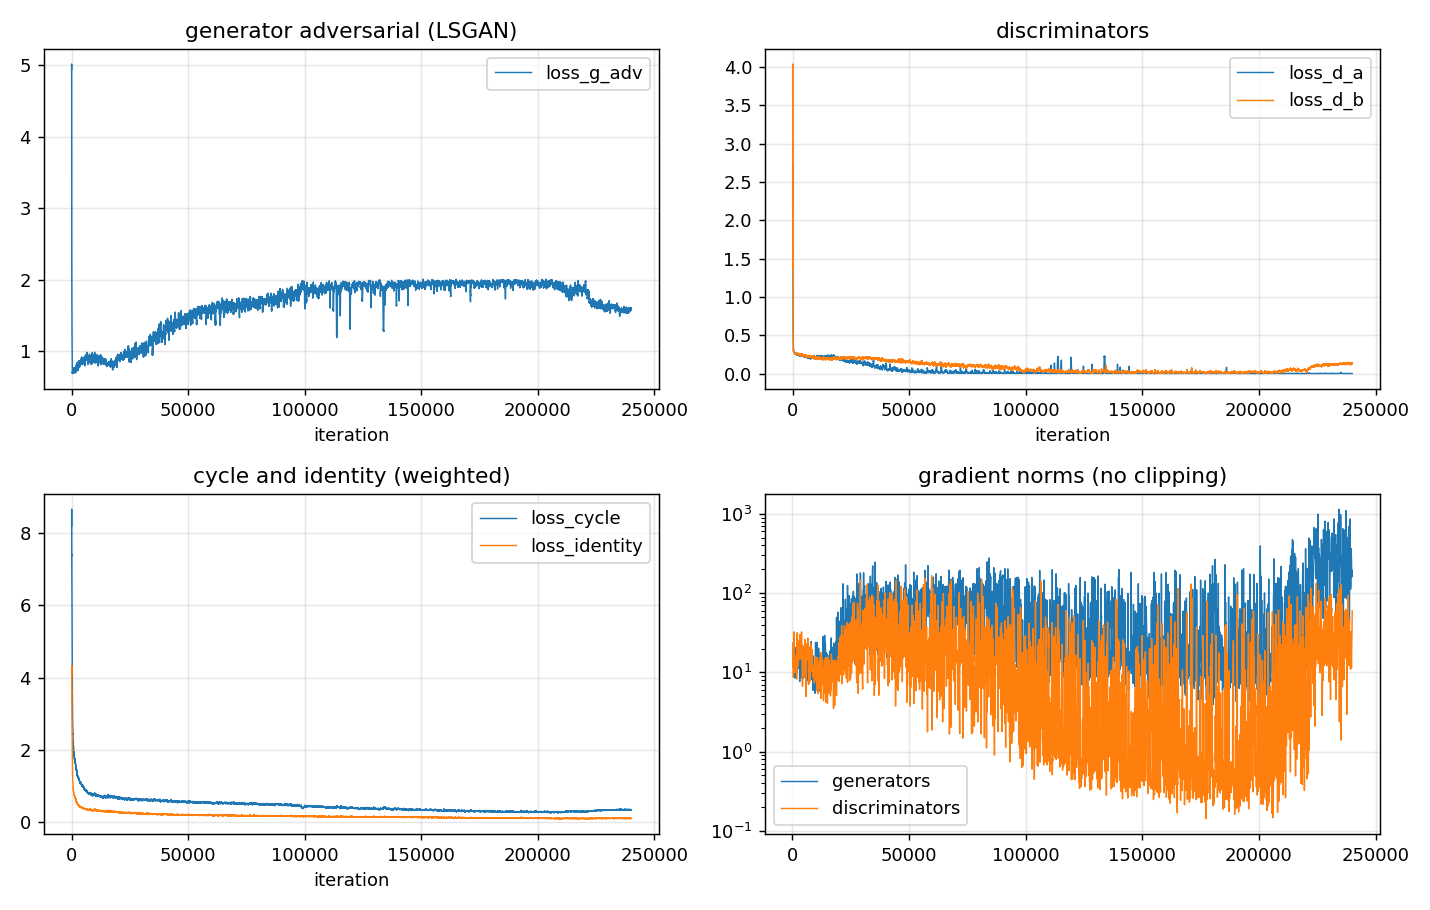

,lr,loss_g,loss_g_adv,loss_cycle,loss_identity,loss_d_a,loss_d_b,elapsed_seconds
epoch,,,,,,,,
111,0.0,2.2370,1.8251,0.3038,0.1081,0.0013,0.0499,28170.7623
112,0.0,2.1128,1.6834,0.3186,0.1108,0.0003,0.0918,28657.2477
113,0.0,2.0965,1.6519,0.3318,0.1128,0.0008,0.1073,29143.0171
114,0.0,2.0928,1.6428,0.3368,0.1132,0.0011,0.1050,29628.6060
115,0.0,2.0610,1.6057,0.3422,0.1131,0.0009,0.1131,30114.3391
116,0.0,2.0770,1.6183,0.3446,0.1141,0.0011,0.1177,30600.2766
117,0.0,2.0765,1.6175,0.3463,0.1127,0.0006,0.1150,31086.1101
118,0.0,2.0485,1.5790,0.3548,0.1147,0.0017,0.1262,31572.8769
119,0.0,2.0403,1.5769,0.3512,0.1121,0.0003,0.1275,32059.0940


,val_fid_a2b,val_fid_b2a,val_fid_mean
epoch,,,
10,114.906,132.351,123.628
20,108.011,126.864,117.438
30,106.787,130.133,118.460
40,108.502,140.765,124.634
50,121.488,123.094,122.291
60,117.826,125.725,121.776
70,120.014,124.038,122.026
80,121.256,123.269,122.262
90,115.342,124.243,119.792


schedule {'epochs': 120, 'decay_start_epoch': 71} | epochs run 120 | stopped at train_until: False | training photos 6138
best validation FID: A2B 106.787 (epoch 30), B2A 123.094 (epoch 50), mean 114.941 | NaN count 0 | max grad norm G 1143.55, D 165.45


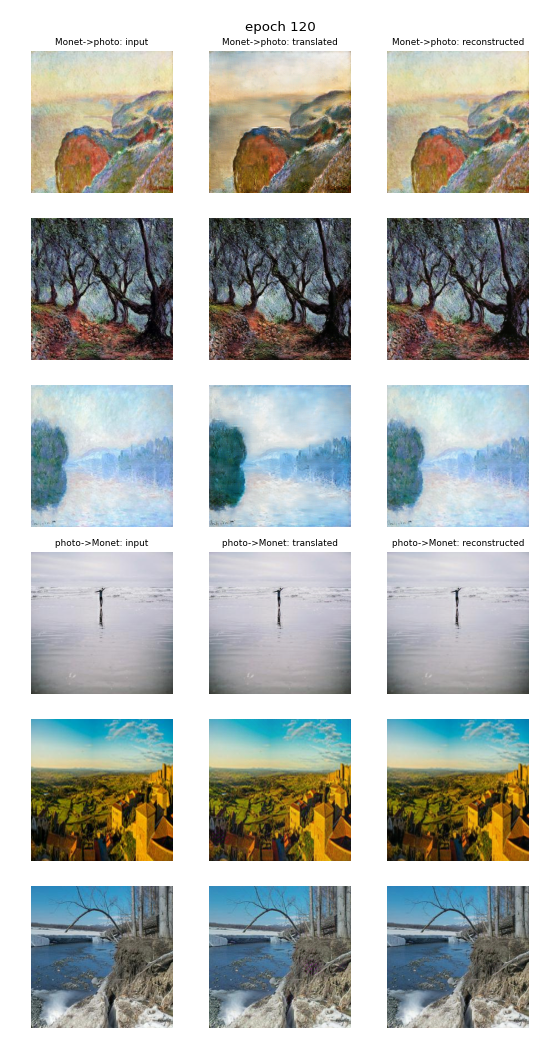

In [12]:
it = pd.read_csv(ITER_CSV)
hist = pd.DataFrame(json.loads(HISTORY.read_text(encoding="utf-8")))
win = max(1, cfg.iters_per_epoch // 10)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, cols, title in ((axes[0, 0], ["loss_g_adv"], "generator adversarial (LSGAN)"),
                        (axes[0, 1], ["loss_d_a", "loss_d_b"], "discriminators"),
                        (axes[1, 0], ["loss_cycle", "loss_identity"], "cycle and identity (weighted)")):
    for c in cols:
        ax.plot(it["iter"], it[c].rolling(win, min_periods=1).mean(), lw=0.8, label=c)
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3); ax.set_xlabel("iteration")
gn = it.dropna(subset=["grad_norm_g"])
axes[1, 1].plot(gn["iter"], gn["grad_norm_g"], lw=0.8, label="generators")
axes[1, 1].plot(gn["iter"], gn["grad_norm_d"], lw=0.8, label="discriminators")
axes[1, 1].set_yscale("log"); axes[1, 1].set_title("gradient norms (no clipping)"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUTPUTS / "loss_curves.png", dpi=130); plt.close(fig)
display(Image(OUTPUTS / "loss_curves.png"))
display(hist.set_index("epoch").round(4).tail(10))
display(pd.DataFrame(summary["validation"]).set_index("epoch").round(3))
print(f"schedule {summary['schedule']} | epochs run {summary['epochs_run']} | stopped at train_until: "
      f"{summary['stopped_at_deadline']} | training photos {summary['train_photos']}")
print(f"best validation FID: A2B {summary['best_val_fid_a2b']:.3f} (epoch {summary['best_epoch_a2b']}), B2A "
      f"{summary['best_val_fid_b2a']:.3f} (epoch {summary['best_epoch_b2a']}), mean {summary['best_val_fid_mean']:.3f} | NaN count "
      f"{summary['nan_count']} | max grad norm G {summary['grad_norm_g_max']:.2f}, D {summary['grad_norm_d_max']:.2f}")
latest = sorted(OUTPUTS.glob("samples_epoch_*.png"))
if latest:
    display(Image(latest[-1], width=480))

## 11. Submission: generate, then score with the PROVIDED script (brief 3.2.5)
- **Which generators:** `generators_best.pt`: each generator from the epoch with its best **validation** FID (EMA weights if `ema=True`).
- **What gets generated:**
  - `pred_A2B/<monet_stem>.jpg` from all 300 Monets
  - `pred_B2A/<photo_stem>.jpg` from the 300 photos in `eval_photos_300.txt`
- **Scoring:** `task3_gan/eval/Part3_Evaluation_Script.ipynb` runs **as provided**. Only its `BASE`, `GEN_A2B` and `GEN_B2A` path lines are
  replaced, and the replaced lines are logged. The script itself writes `submission.csv`. That file, unchanged, is what goes to Kaggle.

In [13]:
def run_provided_script(logger) -> dict:
    nb = json.loads((ROOT / cfg.eval_script).read_text(encoding="utf-8"))
    subs = {r"^BASE\s*=.*$": f"BASE = {str(DATA)!r}",
            r"^GEN_A2B\s*=.*$": f"GEN_A2B    = {str(PRED_A2B)!r}",
            r"^GEN_B2A\s*=.*$": f"GEN_B2A    = {str(PRED_B2A)!r}"}
    ns, cwd, done = {}, os.getcwd(), set()
    os.chdir(OUT)                                          # the script writes submission.csv to the working directory
    try:
        for cell in nb["cells"]:
            if cell["cell_type"] != "code":
                continue
            src = "".join(cell["source"])
            for pat, rep in subs.items():
                new = re.sub(pat, rep, src, flags=re.M)
                if new != src:
                    done.add(pat); logger.info(f"provided script: replaced path line -> {rep}")
                    src = new
            buf = io.StringIO()
            with contextlib.redirect_stdout(buf):
                exec(compile(src, "Part3_Evaluation_Script", "exec"), ns)
            if buf.getvalue().strip():
                logger.info("provided script output: " + buf.getvalue().strip().replace("\n", " | "))
    finally:
        os.chdir(cwd)
    assert done == set(subs), f"could not find the path lines {set(subs) - done} in the provided script"
    return {k: float(ns[k]) for k in ("fid_A2B", "mifid_A2B", "fid_B2A", "mifid_B2A", "sub_fid", "sub_mifid")}


def make_submission() -> dict:
    logger, log_path = open_run_log("submission")
    try:
        ck = torch.load(BEST_GEN, map_location=DEVICE, weights_only=False)
        G_ab, G_ba = build_generator().to(DEVICE), build_generator().to(DEVICE)
        G_ab.load_state_dict(ck["G_A2B"]); G_ba.load_state_dict(ck["G_B2A"])
        logger.info(f"generators {rel(BEST_GEN)} (epochs {json.dumps(ck['epochs'])}, ema {ck['ema']}, validation FID "
                    f"{json.dumps(ck['validation'])}) | sha256 {sha256_file(BEST_GEN)}")
        for d in (PRED_A2B, PRED_B2A):
            shutil.rmtree(d, ignore_errors=True)
        t0 = time.perf_counter()
        translate(G_ab, MONET_DIR, SETS["monet"], PRED_A2B)
        translate(G_ba, PHOTO_DIR, SETS["eval_photos"], PRED_B2A)
        n = len(SETS["monet"]) + len(SETS["eval_photos"])
        logger.info(f"generated {len(list(PRED_A2B.glob('*.jpg')))} A2B and {len(list(PRED_B2A.glob('*.jpg')))} B2A "
                    f"images in {time.perf_counter() - t0:.1f}s ({n / (time.perf_counter() - t0):.1f} images/s)")
        logger.info(f"provided script sha256 {sha256_file(ROOT / cfg.eval_script)}")
        scores = run_provided_script(logger)
        logger.info("submission scores " + json.dumps(scores))
        logger.info(f"submission.csv: {(OUT / 'submission.csv').read_text().strip()!r}")
        if SMOKE:
            logger.warning("SMOKE RUN: this submission.csv is meaningless. Do not submit it.")
        return {**scores, "submission_log": rel(log_path), "generators": rel(BEST_GEN), "best_epochs": ck["epochs"]}
    except BaseException:
        logger.exception("submission stopped with an error")
        raise
    finally:
        close_run_log(logger)


sub = make_submission()
print(pd.read_csv(SUBMISSION).to_string(index=False))

2026-10-06 05:05:26,952 | INFO | config_sha256 31712f3f87ed719f7e5f2c36dd41e44d1f438538704cb3d42d558d97988d11da
2026-10-06 05:05:26,992 | INFO | git_sha unknown | notebook task3_gan/sneha/src/task3_gan_sneha.ipynb
2026-10-06 05:05:26,996 | INFO | device cuda | Tesla T4 | cpu x86_64
2026-10-06 05:05:26,998 | INFO | torch 2.11.0+cu130 | cuda 13.0 | python 3.13.15 | platform Linux-6.6.122+-x86_64-with-glibc2.39
2026-10-06 05:05:27,533 | INFO | log_path reproducibility/raw_logs/sneha/task3_submission_main_20261006T050526Z.log
2026-10-06 05:05:32,014 | INFO | generators task3_gan/sneha/checkpoints/generators_best.pt (epochs {"A2B": 30, "B2A": 50}, ema True, validation FID {"A2B": 106.78721592857485, "B2A": 123.09417606752268}) | sha256 aa1998bdf1812b3bc9cf718ddc18fc33873bceca76b631823aa9b116402759d8
2026-10-06 05:05:39,242 | INFO | generated 300 A2B and 300 B2A images in 7.2s (83.2 images/s)
2026-10-06 05:05:39,245 | INFO | provided script sha256 702a1265433bf2f15c7900c83442c626d10ac0918094

Inception activations: 100%|██████████| 10/10 [00:02<00:00,  4.12it/s]


2026-10-06 05:06:37,815 | INFO | provided script output: Evaluating Photo -> Monet (B2A)  | [Photo->Monet] FID=122.375  MiFID=0.4308 |  |  Evaluating Monet -> Photo (A2B)  | [Monet->Photo] FID=107.897  MiFID=0.4256
2026-10-06 05:06:37,842 | INFO | provided script output: ID         FID     MiFID | 0   1  115.136008  0.428225
2026-10-06 05:06:37,844 | INFO | submission scores {"fid_A2B": 107.89654812596295, "mifid_A2B": 0.42564764618873596, "fid_B2A": 122.37546815665226, "mifid_B2A": 0.4308023452758789, "sub_fid": 115.1360081413076, "sub_mifid": 0.42822499573230743}
2026-10-06 05:06:37,847 | INFO | submission.csv: 'ID,FID,MiFID\n1,115.1360081413076,0.42822499573230743'
 ID        FID    MiFID
  1 115.136008 0.428225


## 12. Every Task 3 metric (brief 3.2), both directions → `metrics_report.csv`
- **Same image sets as the submission:**
  - Monet → photo is scored against `ref_photos_300`, the script's own reference.
  - Photo → Monet is scored against the 300 Monets.
- **FID and MiFID** are the provided script's numbers.
- **Kaggle public/private score and rank** are copied in by hand after submitting. Put them in `results.md`.

In [14]:
@torch.no_grad()
def all_metrics() -> dict:
    logger, log_path = open_run_log("metrics")
    try:
        ck = torch.load(BEST_GEN, map_location=DEVICE, weights_only=False)
        G_ab, G_ba = build_generator().to(DEVICE).eval(), build_generator().to(DEVICE).eval()
        G_ab.load_state_dict(ck["G_A2B"]); G_ba.load_state_dict(ck["G_B2A"])
        monet_p = [MONET_DIR / f"{s}.jpg" for s in SETS["monet"]]
        evalp = [PHOTO_DIR / f"{s}.jpg" for s in SETS["eval_photos"]]
        refp = [PHOTO_DIR / f"{s}.jpg" for s in SETS["ref_photos"]]
        a2b = [PRED_A2B / f"{s}.jpg" for s in SETS["monet"]]
        b2a = [PRED_B2A / f"{s}.jpg" for s in SETS["eval_photos"]]
        f = {k: features(v) for k, v in {"monet": monet_p, "eval": evalp, "ref": refp, "a2b": a2b, "b2a": b2a}.items()}
        r = {"fid_a2b": sub["fid_A2B"], "fid_b2a": sub["fid_B2A"], "fid_mean": sub["sub_fid"],
             "mifid_a2b": sub["mifid_A2B"], "mifid_b2a": sub["mifid_B2A"], "mifid_mean": sub["sub_mifid"]}
        r["kid_a2b_mean"], r["kid_a2b_std"] = kid(f["ref"], f["a2b"])
        r["kid_b2a_mean"], r["kid_b2a_std"] = kid(f["monet"], f["b2a"])
        r["density_a2b"], r["coverage_a2b"] = density_coverage(f["ref"], f["a2b"])
        r["density_b2a"], r["coverage_b2a"] = density_coverage(f["monet"], f["b2a"])
        r["content_cos_a2b"] = cosine_pairs(f["monet"], f["a2b"])        # input vs its translation, by stem
        r["content_cos_b2a"] = cosine_pairs(f["eval"], f["b2a"])
        lp = lpips.LPIPS(net="alex", verbose=False).to(DEVICE).eval()
        cyc, lps = {"a": [], "b": []}, {"a2b": [], "b2a": []}
        for (folder, stems, G1, G2, kc, kl) in ((MONET_DIR, SETS["monet"], G_ab, G_ba, "a", "a2b"),
                                                (PHOTO_DIR, SETS["eval_photos"], G_ba, G_ab, "b", "b2a")):
            for i in range(0, len(stems), 8):
                x = to_model(load_images(folder, stems[i:i + 8])).to(DEVICE)
                y = G1(x)
                cyc[kc].append((G2(y) - x).abs().mean(dim=(1, 2, 3)).cpu())
                lps[kl].append(lp(x, y).flatten().cpu())
        r["cycle_l1_a"], r["cycle_l1_b"] = (float(torch.cat(cyc[k]).mean()) for k in ("a", "b"))
        r["lpips_a2b"], r["lpips_b2a"] = (float(torch.cat(lps[k]).mean()) for k in ("a2b", "b2a"))
        s = summary
        r.update({"final_cycle_loss": s["final_cycle_loss"], "final_identity_loss": s["final_identity_loss"],
                  "grad_norm_g_max": s["grad_norm_g_max"], "grad_norm_d_max": s["grad_norm_d_max"],
                  "nan_count": s["nan_count"], "param_count_total": s["param_count_total"],
                  "param_count_generator": s["params"]["G_A2B"], "param_count_discriminator": s["params"]["D_A"],
                  "train_seconds": s["train_seconds"], "images_per_sec": s["images_per_sec"],
                  "peak_mem_gb": s["peak_mem_gb"], "device_name": s["device_name"], "cpu_name": s["cpu_name"],
                  "generator": cfg.generator, "ema": cfg.ema, "diffaugment": cfg.diffaugment,
                  "epochs_run": s["epochs_run"], "epochs_planned": s["schedule"]["epochs"],
                  "stopped_at_deadline": s["stopped_at_deadline"], "train_photos": s["train_photos"],
                  "best_epoch_a2b": ck["epochs"]["A2B"], "best_epoch_b2a": ck["epochs"]["B2A"],
                  "best_val_fid_mean": s["best_val_fid_mean"],
                  "n_a2b": len(a2b), "n_b2a": len(b2a), "checkpoint": rel(BEST_GEN), "config_sha256": CFG_HASH,
                  "kaggle_public": "", "kaggle_private": "", "kaggle_rank": ""})
        pd.DataFrame([r]).to_csv(METRICS_CSV, index=False, encoding="utf-8")
        logger.info("metrics " + json.dumps({k: (round(v, 6) if isinstance(v, float) else v) for k, v in r.items()}))
        r["metrics_log"] = rel(log_path)
        return r
    except BaseException:
        logger.exception("metrics stopped with an error")
        raise
    finally:
        close_run_log(logger)


metrics = all_metrics()
pd.Series({k: v for k, v in metrics.items() if k != "metrics_log"}).to_frame("value")

2026-10-06 05:06:37,892 | INFO | config_sha256 31712f3f87ed719f7e5f2c36dd41e44d1f438538704cb3d42d558d97988d11da
2026-10-06 05:06:37,895 | INFO | git_sha unknown | notebook task3_gan/sneha/src/task3_gan_sneha.ipynb
2026-10-06 05:06:37,896 | INFO | device cuda | Tesla T4 | cpu x86_64
2026-10-06 05:06:37,897 | INFO | torch 2.11.0+cu130 | cuda 13.0 | python 3.13.15 | platform Linux-6.6.122+-x86_64-with-glibc2.39
2026-10-06 05:06:38,418 | INFO | log_path reproducibility/raw_logs/sneha/task3_metrics_main_20261006T050637Z.log


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


2026-10-06 05:07:14,247 | INFO | metrics {"fid_a2b": 107.896548, "fid_b2a": 122.375468, "fid_mean": 115.136008, "mifid_a2b": 0.425648, "mifid_b2a": 0.430802, "mifid_mean": 0.428225, "kid_a2b_mean": 0.019739, "kid_a2b_std": 0.002094, "kid_b2a_mean": 0.028168, "kid_b2a_std": 0.002483, "density_a2b": 0.877333, "coverage_a2b": 0.78, "density_b2a": 0.283333, "coverage_b2a": 0.42, "content_cos_a2b": 0.89455, "content_cos_b2a": 0.9375, "cycle_l1_a": 0.040079, "cycle_l1_b": 0.028598, "lpips_a2b": 0.132078, "lpips_b2a": 0.11077, "final_cycle_loss": 0.352437, "final_identity_loss": 0.112139, "grad_norm_g_max": 1143.547729, "grad_norm_d_max": 165.446732, "nan_count": 0, "param_count_total": 114371976, "param_count_generator": 54419459, "param_count_discriminator": 2766529, "train_seconds": 32599.624609, "images_per_sec": 15.009055, "peak_mem_gb": 12.696199, "device_name": "Tesla T4", "cpu_name": "x86_64", "generator": "unet256", "ema": true, "diffaugment": "translation,cutout", "epochs_run": 120,

,value
fid_a2b,107.896548
fid_b2a,122.375468
fid_mean,115.136008
mifid_a2b,0.425648
mifid_b2a,0.430802
mifid_mean,0.428225
kid_a2b_mean,0.019739
kid_a2b_std,0.002094
kid_b2a_mean,0.028168
kid_b2a_std,0.002483


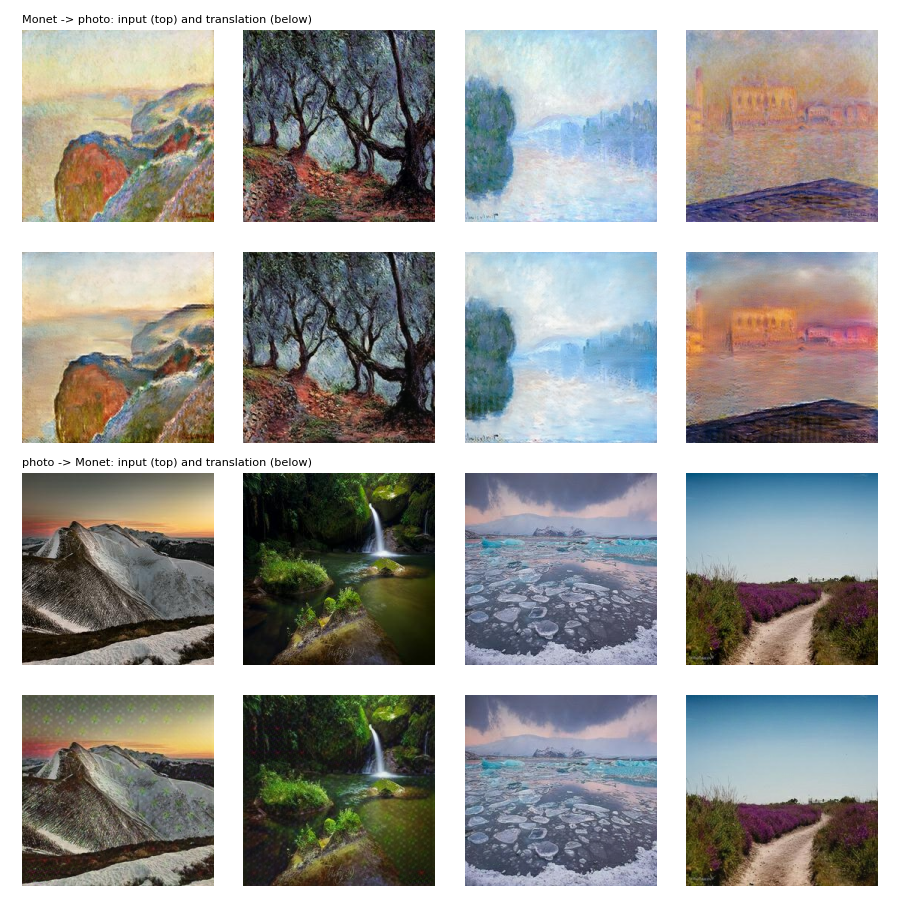

In [15]:
pairs = [(MONET_DIR, PRED_A2B, SETS["monet"], "Monet -> photo"), (PHOTO_DIR, PRED_B2A, SETS["eval_photos"], "photo -> Monet")]
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for r, (src, dst, stems, title) in enumerate(pairs):
    for i, s in enumerate(stems[:4]):               # the first stems by filename, not hand-picked
        axes[2 * r, i].imshow(PILImage.open(src / f"{s}.jpg")); axes[2 * r, i].axis("off")
        axes[2 * r + 1, i].imshow(PILImage.open(dst / f"{s}.jpg")); axes[2 * r + 1, i].axis("off")
    axes[2 * r, 0].set_title(f"{title}: input (top) and translation (below)", loc="left", fontsize=9)
fig.tight_layout(); fig.savefig(OUTPUTS / "translations_first4.png", dpi=90); plt.close(fig)
display(Image(OUTPUTS / "translations_first4.png"))

## 13. Blinded human audit (team; brief 3.2.6)
- **Drawing the 30 samples:** the first cell runs once **both** members' `pred_*` folders exist. With a fixed seed, it draws 30 fixed samples across both members and
  both directions, shuffles them, and saves each as `audit_XX.jpg` (input beside translation) in `task3_gan/audit/`. It also writes `audit_key.json`.
  **Commit the key, but don't open it** until both rating sheets are committed.
- **Rating:** each of you fills in your own copy of `ratings_template.csv` (1–5 for style, content and artifacts), without discussing.
- **Agreement:** the second cell then computes quadratic-weighted Cohen's kappa per axis, plus exact and within-1 agreement.

In [16]:
AUDIT = ROOT / "task3_gan" / "audit"
members = sorted(p.name for p in (ROOT / "task3_gan").iterdir()
                 if p.is_dir() and (p / "outputs" / "pred_A2B").is_dir() and (p / "outputs" / "pred_B2A").is_dir())
if SMOKE or len(members) < 2:
    print(f"audit set not built: needs both members' outputs (found {members}){' and a real run' if SMOKE else ''}")
elif (AUDIT / "audit_key.json").exists():
    print(f"audit set already exists in {rel(AUDIT)} (fixed; not redrawn)")
else:
    AUDIT.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(42)
    groups = {}                                      # (member, direction) -> stems that member generated
    for m in members:
        for direction, stems in (("A2B", SETS["monet"]), ("B2A", SETS["eval_photos"])):
            groups[(m, direction)] = [s for s in stems
                                      if (ROOT / "task3_gan" / m / "outputs" / f"pred_{direction}" / f"{s}.jpg").exists()]
    keys = sorted(groups)
    quota = {k: 30 // len(keys) + (1 if i < 30 % len(keys) else 0) for i, k in enumerate(keys)}   # 8, 8, 7, 7
    chosen = [(k[0], k[1], groups[k][i]) for k in keys
              for i in sorted(rng.choice(len(groups[k]), quota[k], replace=False))]
    order = rng.permutation(len(chosen))
    key = {}
    for n, i in enumerate(order, 1):
        m, direction, s = chosen[i]
        src = (MONET_DIR if direction == "A2B" else PHOTO_DIR) / f"{s}.jpg"
        dst = ROOT / "task3_gan" / m / "outputs" / f"pred_{direction}" / f"{s}.jpg"
        canvas = PILImage.new("RGB", (512, 256)); canvas.paste(PILImage.open(src).convert("RGB"), (0, 0))
        canvas.paste(PILImage.open(dst).convert("RGB"), (256, 0)); canvas.save(AUDIT / f"audit_{n:02d}.jpg", quality=95)
        key[f"audit_{n:02d}"] = {"member": m, "direction": direction, "stem": s}
    (AUDIT / "audit_key.json").write_text(json.dumps(key, indent=1), encoding="utf-8")
    pd.DataFrame({"sample": list(key), "style": "", "content": "", "artifacts": ""}).to_csv(
        AUDIT / "ratings_template.csv", index=False)
    print(f"built {len(key)} audit samples in {rel(AUDIT)}; copy ratings_template.csv to ratings_<rater>.csv each")

audit set not built: needs both members' outputs (found ['sneha'])


In [17]:
sheets = sorted(AUDIT.glob("ratings_*.csv")) if AUDIT.exists() else []
sheets = [p for p in sheets if p.name != "ratings_template.csv"]
if len(sheets) == 2:
    r1, r2 = (pd.read_csv(p).set_index("sample").sort_index() for p in sheets)
    agree = {axis: audit_agreement(r1[axis].astype(int).to_numpy(), r2[axis].astype(int).to_numpy())
             for axis in ("style", "content", "artifacts")}
    out = pd.DataFrame(agree).T
    out.loc["mean score (both raters)"] = [float(pd.concat([r1, r2])[["style", "content", "artifacts"]].mean().mean()), "", ""]
    out.to_csv(AUDIT / "agreement.csv")
    display(out)
else:
    print(f"agreement not computed: needs exactly two filled sheets ratings_<rater>.csv in task3_gan/audit/ (found {len(sheets)})")

agreement not computed: needs exactly two filled sheets ratings_<rater>.csv in task3_gan/audit/ (found 0)


## 14. Manifest

In [18]:
manifest = {
    "member": cfg.member, "task": "task3", "run_name": cfg.run_name, "config_sha256": CFG_HASH,
    "notebook": "task3_gan/sneha/src/task3_gan_sneha.ipynb", "git_sha": git_sha(), "seed": cfg.seed,
    "timestamp_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "python": platform.python_version(), "platform": platform.platform(), "torch": torch.__version__,
    "cuda": torch.version.cuda, "device": device_name(DEVICE), "cpu": cpu_name(), "packages": installed_packages(),
    "data": {"lists_sha256": LIST_SHA, "n_monet": len(monet_all), "n_photo": len(photo_all)},
    "eval_script": {"path": cfg.eval_script, "sha256": sha256_file(ROOT / cfg.eval_script),
                    "changed": "only the BASE, GEN_A2B and GEN_B2A path lines"},
    "checkpoints": {p.name: {"path": rel(p), "sha256": sha256_file(p), "bytes": p.stat().st_size,
                             "storage": "too large for GitHub: upload to Git LFS or a shared drive and put the link here"}
                    for p in (BEST_GEN, FINAL_GEN)},
    "submission": {"csv": rel(SUBMISSION), "sha256": sha256_file(SUBMISSION), "generators": sub["generators"],
                   "best_epochs": sub["best_epochs"], "schedule": summary["schedule"], "pred_A2B": rel(PRED_A2B), "pred_B2A": rel(PRED_B2A)},
    "metric_rows": {rel(BEST_GEN): {"csv": rel(METRICS_CSV), "row": 1}},
    "raw_logs": [summary["train_log"], sub["submission_log"], metrics["metrics_log"]],
    "evidence": {"loss_curves": rel(OUTPUTS / "loss_curves.png"), "iterations_csv": rel(ITER_CSV),
                 "samples": sorted(rel(p) for p in OUTPUTS.glob("samples_epoch_*.png"))},
    "config": dict(cfg),
}
MANIFEST.write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")
print("manifest:", rel(MANIFEST))
for n, c in manifest["checkpoints"].items():
    print(f"  {n}: {c['bytes'] / 1e6:.0f} MB | sha256 {c['sha256'][:16]}...")
print("raw logs:", *manifest["raw_logs"], sep="\n  ")

manifest: reproducibility/manifests/sneha_task3.json
  generators_best.pt: 435 MB | sha256 aa1998bdf1812b3b...
  generators_final.pt: 435 MB | sha256 bc2fff422ad630b6...
raw logs:
  reproducibility/raw_logs/sneha/task3_train_main_20261006T022031Z.log
  reproducibility/raw_logs/sneha/task3_submission_main_20261006T050526Z.log
  reproducibility/raw_logs/sneha/task3_metrics_main_20261006T050637Z.log


## 15. Analysis
In the write-ups: visual quality, the cycle-consistency check, training stability, shortcomings, and the Kaggle rank are in
[`../results.md`](../results.md). Shortcomings with image evidence are in [`../failure_analysis.md`](../failure_analysis.md).

## 16. Google Colab only: copy the results to Drive
Copies every file of the run to `data266_task3/backup/` and adds a results zip (`pack_results.py`, without the resume checkpoint)
to `data266_task3/`. Then save the notebook (*File → Save*) and download it (*File → Download → .ipynb*).

In [19]:
if COLAB:
    n = colab_backup(final=True)
    packed = subprocess.run([sys.executable, "pack_results.py"], check=True, capture_output=True, text=True).stdout
    z = max(LOCAL.glob("sneha_results_*.zip"), key=lambda p: p.stat().st_mtime)
    shutil.copyfile(z, DRIVE_DIR / f"{z.stem}_colab_step{STEP}.zip")
    print(f"{n} files copied to {BACKUP}\n{packed.splitlines()[0]}\nresults zip -> {DRIVE_DIR / f'{z.stem}_colab_step{STEP}.zip'}")
else:
    print("not on Colab: nothing to do")

613 files copied to /content/drive/MyDrive/data266_task3/backup
wrote sneha_results_20261006T050728Z.zip: 664 files, 918 MB
results zip -> /content/drive/MyDrive/data266_task3/sneha_results_20261006T050728Z_colab_stepB.zip
